In [1]:
# A carrier object has an ID and dictionaries with all Vehicles and all Services
class Carrier:  
    """
    This class represents a Carrier with an ID and dictionaries with all Vehicles and all Services.
    """
        
    def __init__(self, carrierID): 
        self.carrierID = carrierID 
        self.vehicles = {} 
        self.services = {}   
        self.missedDeliveries = []
        self.logisticProvider = getProviderFromID(self.carrierID)
        
    def __str__(self):
        return "[Carrier ID: " + str(self.carrierID) + " with " + str(len(self.vehicles)) + " Vehicles and " + str(len(self.services)) + " Services]"
    
    def __repr__(self):
        return self.__str__()
    
    def getNumberOfVehicles(self):
        return (len(self.vehicles))
    
    def getNumberOfServices(self):
        return (len(self.services))
        
    def addVehicle(self, vehicle): 
        self.vehicles[vehicle.getVehicleId] = vehicle
        
    def addService(self, service): 
        self.services[service.getServiceID] = service

    def getTotalNumberofServices(self):  
        return sum((s.getDemand() for s in self.services.values()))
    
    def getProvider(self):
        return self.logisticProvider
    
    def getServices(self): 
        return [s for s in self.services.values()]   
    
    def getCarrierId(self): 
        return self.carrierID    
    
    def getVehicles(self): 
        return self.vehicles
    
    def getMissedDeliveries(self): 
        return self.missedDeliveries  
    
    def setMissedDeliveries(self, missDeliveries): 
        self.missedDeliveries = missDeliveries


# A Vehicle has an ID, a Typ and you can add Plans to this vehicles with services and Routes. 
# These Vehicles / Plans have to be converted to Sumo! 
class Vehicle: 
    """
    This class represents a Vehicle with an ID, a Type and you can add Plans to this vehicles with services and Routes.
    """
        
    def __init__(self, vehicleID, vehicleType): 
        self.vehicleID = vehicleID 
        self.vehicleType = vehicleType 
        self.plans = []
        
    def __str__(self):
        return "[Vehicle ID: " + str(self.vehicleID) + " with Type: " + self.vehicleType +"]"
    
    def __repr__(self):
        return self.__str__()
    
    def addVehiclePlan(self, plan): 
        self.plans.append(plan)
        
    def changeVehicleType(self, vehicleType): 
        self.vehicleType == vehicleType
        
    def getVehicleId(self): 
        return self.vehicleID
    
    def getPlans(self):
        return self.plans


# A Plan is a sequence of Activies (start, service, service, ... , end)
# all important Information are stored in the activities / legs dictionary
# The Order of the sequence is stored as a list called "planSequence"
class Plan:  
    """
    This class represents a Plan which is a sequence of Activities (start, service, service, ... , end).
    """
        
    def __init__(self, planId, vehicle, activities, legs): 
        self.planId = planId
        self.vehicle = vehicle
        self.activities = activities 
        self.legs = legs 
        self.planSequence = [] 
        
    def __str__(self):
        return "[Plan ID: " + str(self.planId) + " with " + str(len(self.activities)) +" Activities and " + str(len(self.legs)) + " Legs]"
    
    def __repr__(self):
        return self.__str__()
    
    def getPlanSequence(self):
        return self.planSequence
    
    def createInternalPlanSequence(self):
        for i in range (len(self.legs)):            
            self.planSequence.append(get_nth_key(self.activities, i))
            self.planSequence.append(get_nth_key(self.legs, i))
        self.planSequence.append(get_nth_key(self.activities, len(self.activities)-1))    

# A Service is a data container storing all available information from the CSV/XML
class Service:
    """
    Data container for a delivery/pickup service.
    All durations are stored in seconds (int).
    Extra attributes are kept in a dict.
    """

    def __init__(self, serviceType, serviceID, capacityDemand, duration, link, extra_attributes=None):
        self.serviceType = serviceType
        self.serviceID = serviceID
        self.capacityDemand = capacityDemand
        # ensure duration is numeric seconds
        try:
            self.duration = int(duration)
        except Exception:
            self.duration = 0
        self.link = link
        self.extra_attributes = extra_attributes or {}

        # optional: vehicleType placeholder if you need it later
        self.vehicleType = self.extra_attributes.get("vehicleType", None)

    def __str__(self):
        return f"[Service ID: {self.serviceID} (Type: {self.serviceType}) with a CapacityDemand of {self.capacityDemand} to Link: {self.link}]"

    __repr__ = __str__

    # --- attributes API ---
    def getAttribute(self, key, default=None):
        return self.extra_attributes.get(key, default)

    def setAttribute(self, key, value):
        self.extra_attributes[key] = value

    # --- typed getters/setters ---
    def getServiceType(self):
        return self.serviceType

    def changeVehicleType(self, vehicleType):
        # was '==' before (no effect). Should assign.
        self.vehicleType = vehicleType
        self.extra_attributes["vehicleType"] = vehicleType

    def getDemand(self):
        return self.capacityDemand

    def getServiceID(self):
        return self.serviceID

    def getServiceLink(self):
        return self.link

    def setServiceLink(self, link):
        self.link = link

    def getDuration(self):
        """Return dwell time in seconds."""
        return int(self.duration)

    def setDuration(self, duration_s):
        """Set dwell time in seconds."""
        self.duration = int(duration_s)
        
        
        
# Get Logistic Provider from XML ID
def getProviderFromID(carrierID):
    """
    This function returns the provider name based on the carrier ID.
    
    Args:
        carrierID (str): The ID of the carrier.
        
    Returns:
        str: The name of the provider.
    """
        
    if("dhl" in str(carrierID)):
        return "dhl"  
    elif("amazon" in str(carrierID)):
        return "amazon"  
    elif("ups" in str(carrierID)):
        return "ups"  
    elif("gls" in str(carrierID)):
        return "gls"  
    elif("dpd" in str(carrierID)):
        return "dpd"  
    elif("fedex" in str(carrierID)):
        return "fedex"  
    elif("hermes" in str(carrierID)):
        return "hermes"  
    elif("wl" in str(carrierID)):
        return "White-Label"  
    else:
        raise ValueError('Carrier Provider unknown: ' + str(carrierID))
    
# Method returning the index of an element of a dictionary
def get_nth_key(dictionary, n=0):
    """
    This function returns the nth key of a dictionary.
    
    Args:
        dictionary (dict): The dictionary to get the key from.
        n (int): The index of the key to get. Default is 0.
        
    Returns:
        key: The nth key of the dictionary.
    """
        
    if n < 0:
        n += len(dictionary)
    for i, key in enumerate(dictionary.keys()):
        if i == n:
            return key
    raise IndexError("dictionary index out of range") 

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

plt.rcdefaults()                     # reset rcParams
mpl.rcParams.update(mpl.rcParamsDefault)
plt.style.use('default')             # reset style

sns.set_style("whitegrid")

In [3]:
import os
import re
import pickle
import pandas as pd

# --- Paths ---
BATCH_DIR = r"C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch"
OUTPUT_BASE = os.path.join(BATCH_DIR, r"processed")

# --- Helper to load pickles ---
def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

# Only files like <run>_emissions_result.pkl
PATTERN = re.compile(r"^(?P<run>.+)_result\.pkl$", re.ASCII)

def load_all_operating_result(output_base):
    """
    Returns:
      results_by_run: dict run_name -> object loaded from pickle
      df_all: DataFrame concatenated across runs if each is a DataFrame
              otherwise None
    """
    results_by_run = {}
    frames = []

    for root, _, files in os.walk(output_base):
        for fn in files:
            m = PATTERN.match(fn)
            if not m:
                continue
            run_name = m.group("run")
            p = os.path.join(root, fn)
            try:
                obj = load_pickle(p)
            except Exception as e:
                print(f"[WARN] Could not load {p}: {e}")
                continue

            results_by_run[run_name] = obj

            # If the object is a DataFrame, collect for concatenation
            if isinstance(obj, pd.DataFrame):
                df = obj.copy()
                if "run_name" not in df.columns:
                    df["run_name"] = run_name
                frames.append(df)

    df_all = pd.concat(frames, ignore_index=True) if frames else None
    print(f"[INFO] Loaded emissions_result for {len(results_by_run)} runs from {output_base}")
    if df_all is not None:
        print("[INFO] Concatenated DataFrame shape:", df_all.shape)
    return results_by_run, df_all

# --- Execute load ---
results_by_run, df_all = load_all_operating_result(OUTPUT_BASE)

# Example: inspect keys and one sample
print("Runs:", list(results_by_run.keys())[:10])

# If you want just the combined table:
if df_all is not None:
    display(df_all.head())


[INFO] Loaded emissions_result for 48 runs from C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed
[INFO] Concatenated DataFrame shape: (119073, 62)
Runs: ['basecase_12052025_iter150_jsprit100', 'basecase_13052025_iter150_jsprit100', 'basecase_14052025_iter150_jsprit100', 'basecase_15052025_iter150_jsprit100', 'basecase_16052025_iter150_jsprit100', 'basecase_17052025_iter150_jsprit100', 'batchhigh_12052025_iter150_jsprit100', 'batchhigh_13052025_iter150_jsprit100', 'batchhigh_14052025_iter150_jsprit100', 'batchhigh_15052025_iter150_jsprit100']


,vehicle_id,Start time,End time,Tour Duration (hrs),Service Duration,Driving Time (hrs),Start time formatted,End time formatted,Tour Duration formatted,Service Duration formatted,...,run_name,Tour Duration,Travel Duration,tour_km,initial_delivery_distance,vehicle_load_factor,is_van,is_ev,emissions,main_area_type_name
0,freight_fedex_31832_veh_cep_size_m_7_1,24139.0,72066.0,13.313056,18233.0,8.248333,1970-01-01 06:42:19,1970-01-01 20:01:06,1970-01-01 13:18:47,1970-01-01 05:03:53,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,freight_gls_31535_veh_cep_size_l_7_1,24722.0,64152.0,10.952778,10584.0,8.012778,1970-01-01 06:52:02,1970-01-01 17:49:12,1970-01-01 10:57:10,1970-01-01 02:56:24,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,freight_ups_31311_veh_cep_size_m_7_1,25075.0,69743.0,12.407778,14136.0,8.481111,1970-01-01 06:57:55,1970-01-01 19:22:23,1970-01-01 12:24:28,1970-01-01 03:55:36,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,freight_ups_31832_veh_cep_size_m_7_1,25101.0,72941.0,13.288889,17985.0,8.293056,1970-01-01 06:58:21,1970-01-01 20:15:41,1970-01-01 13:17:20,1970-01-01 04:59:45,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,freight_gls_31535_veh_cep_size_m_7_5,25208.0,63241.0,10.564722,11392.0,7.400278,1970-01-01 07:00:08,1970-01-01 17:34:01,1970-01-01 10:33:53,1970-01-01 03:09:52,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df_all = df_all[df_all["Vehicle Utilization (%)"] > 0.05]

In [5]:
df_all["Cost per Parcel [€/parcel]"] =  df_all["vehicle_cost"] / df_all["deliveries"] 

In [6]:
import pandas as pd

# Example: df_all["run_name"] = ["basecase_12052025_iter150_jsprit100", "basecase_13052025_iter150_jsprit100", ...]

# Function to extract weekday name from run_name
def extract_weekday_from_runname(run_name):
    """
    Extracts date (DDMMYYYY) from run_name like 'basecase_12052025_iter150_jsprit100'
    and returns the corresponding weekday name ('Monday', 'Tuesday', ...)
    """
    import re
    from datetime import datetime

    m = re.search(r"_(\d{8})_", run_name)
    if not m:
        return None
    date_str = m.group(1)
    try:
        dt = datetime.strptime(date_str, "%d%m%Y")
        return dt.strftime("%A")  # English weekday name
    except Exception:
        return None

# Apply to your DataFrame
df_all["weekday"] = df_all["run_name"].astype(str).apply(extract_weekday_from_runname)

# Optional: if you prefer English names even when German ones are present
weekday_map = {
    "Montag": "Monday",
    "Dienstag": "Tuesday",
    "Mittwoch": "Wednesday",
    "Donnerstag": "Thursday",
    "Freitag": "Friday",
    "Samstag": "Saturday",
    "Sonntag": "Sunday",
}
df_all["weekday"] = df_all["weekday"].replace(weekday_map)

# Inspect result
print(df_all[["run_name", "weekday"]].head())

weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']

# Ensure scenario column from run_name prefix
if "scenario" not in df_all.columns:
    if "run_name" not in df_all.columns:
        raise RuntimeError("Column 'run_name' is missing in df_all.")
    df_all["scenario"] = df_all["run_name"].astype(str).str.split("_").str[0]


                              run_name weekday
0  basecase_12052025_iter150_jsprit100  Monday
1  basecase_12052025_iter150_jsprit100  Monday
2  basecase_12052025_iter150_jsprit100  Monday
3  basecase_12052025_iter150_jsprit100  Monday
4  basecase_12052025_iter150_jsprit100  Monday


In [7]:
import numpy as np
# Filter tours: Mixed carrier, Urban area, Wednesday, scenario = batchhigh

import re
from datetime import datetime

df = df_all.copy()

# Ensure scenario column from run_name prefix
if "scenario" not in df.columns:
    if "run_name" not in df.columns:
        raise RuntimeError("Column 'run_name' is missing in df_all.")
    df["scenario"] = df["run_name"].astype(str).str.split("_").str[0]



# Provider active batch days (English weekday names)
provider_active_days = {
    "dhl": {"Monday", "Wednesday", "Friday"},
    "hermes": {"Tuesday", "Saturday"},
    "dpd": {"Tuesday", "Friday"},
    "gls": {"Monday", "Thursday"},
    "ups": {"Monday", "Thursday"},
    "amazon": {"Tuesday", "Thursday", "Saturday"},
    "fedex": {"Monday", "Thursday"},
}

def _is_active(row):
    prov = str(row.get("provider", "")).strip().lower()
    wd = str(row.get("weekday", "")).strip()
    days = provider_active_days.get(prov, set())
    return wd in days

df["active_flag"] = df.apply(_is_active, axis=1)
df["activity_group"] = np.where(
    df["active_flag"],
    "Batch Delivery Day",
    "Non-batch Delivery Day"
)

# Area column can be area_type_agg or area_type
area_col = "area_type_agg" if "area_type_agg" in df.columns else ("area_type" if "area_type" in df.columns else None)
if area_col is None:
    raise RuntimeError("Neither 'area_type_agg' nor 'area_type' is present in df_all.")

# Robust alias mapping: raw -> canonical
rename_to_canonical = {
    "Tour Length (km)": "Distance per Tour (km)",
    "delivery_area_km2": "Delivery Area (km^2)",
    "deliveries_per_stop": "Deliveries per Stop",
}

# Apply mapping only for columns that exist
rename_actual = {raw: canon for raw, canon in rename_to_canonical.items() if raw in df.columns}
df.rename(columns=rename_actual, inplace=True)

# Canonical KPI list for downstream code
kpis = [
    "Vehicle Utilization (%)",
    "Distance per Tour (km)",
    "Initial Delivery Distance (km)",
    "Mean Distance Between Stops (km)",
    "Delivery Area (km^2)",
    "Deliveries per Stop",
    # add if you want it in the plot/table:
    "Driving Share of Tour (%)",
]

# Ensure all KPI columns are numeric
for c in kpis:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Optional sanity check
missing_kpis = [c for c in kpis if c not in df.columns]
if missing_kpis:
    print("[WARN] Missing KPI columns after rename:", missing_kpis)





In [8]:
# KPIs, nur die die du im Plot nutzt
# Canonical KPI list for downstream code
kpis = [
    "Vehicle Utilization (%)",
    "Distance per Tour (km)",
    "Initial Delivery Distance (km)",
    "Mean Distance Between Stops (km)",
    "Delivery Area (km^2)",
    "Deliveries per Stop",
    # add if you want it in the plot/table:
    "Driving Share of Tour (%)",
]
# Vektorisiert sicherstellen, dass es numerisch ist
for c in kpis:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Szenario-Mittel je activity_group x weekday x scenario
grp = ["activity_group", "weekday", "scenario"]
if "run_name" in df.columns:
    per_run = df.groupby(grp + ["run_name"], dropna=False)[kpis].mean().reset_index()
    scen_avg = per_run.groupby(grp, dropna=False)[kpis].mean().reset_index()
else:
    scen_avg = df.groupby(grp, dropna=False)[kpis].mean().reset_index()

# Baseline erkennen
def _detect_baseline(cands):
    keys = ["basecase","baseline","base","bau","ref","reference","statusquo","status_quo","status-quo","basis","default"]
    for k in keys:
        for s in cands:
            if k in str(s).lower():
                return s
    return None

BASELINE = _detect_baseline(scen_avg["scenario"].astype(str).unique().tolist()) or \
           sorted(scen_avg["scenario"].astype(str).unique().tolist())[0]

# Baseline je activity_group x weekday
base = (
    scen_avg[scen_avg["scenario"] == BASELINE]
    .loc[:, ["activity_group","weekday"] + kpis]
    .rename(columns={c: f"base__{c}" for c in kpis})
)

# Merge und Prozentdeltas
m = scen_avg.merge(base, on=["activity_group","weekday"], how="left")

for c in kpis:
    num = pd.to_numeric(m[c], errors="coerce")
    den = pd.to_numeric(m[f"base__{c}"], errors="coerce")
    # Prozentdelta, Inf -> NaN
    m[c] = (num / den - 1.0) * 100.0
m[kpis] = m[kpis].replace([np.inf, -np.inf], np.nan)

# Das ist deine saubere Tabelle für den Plot
pct_tbl = m[["activity_group","weekday","scenario"] + kpis].copy()

# Debug: prüfe, ob Baseline je Gruppe vorhanden ist
pct_tbl

,activity_group,weekday,scenario,Vehicle Utilization (%),Distance per Tour (km),Initial Delivery Distance (km),Mean Distance Between Stops (km),Delivery Area (km^2),Deliveries per Stop,Driving Share of Tour (%)
0,Batch Delivery Day,Friday,basecase,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,Batch Delivery Day,Friday,batchhigh,3.969037,-12.955096,18.345289,17.573777,23.303562,65.246817,-12.572324
2,Batch Delivery Day,Friday,batchmedium,3.696106,-9.664197,19.121608,20.591875,31.426478,60.546884,-10.786673
3,Batch Delivery Day,Friday,batchmoderate,0.520690,-5.624324,6.847816,3.805297,-18.054764,19.409891,-7.376012
4,Batch Delivery Day,Monday,basecase,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,Batch Delivery Day,Monday,batchhigh,4.953727,-18.038602,9.731035,-0.685345,-34.547478,60.280761,-13.989055
6,Batch Delivery Day,Monday,batchmedium,3.984435,1.611932,16.011666,39.818763,68.066630,46.328740,-1.565291
7,Batch Delivery Day,Monday,batchmoderate,3.829094,-5.931446,7.575808,1.048560,-17.532545,24.041161,-6.300760
8,Batch Delivery Day,Saturday,basecase,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,Batch Delivery Day,Saturday,batchhigh,11.931385,-14.891603,4.857483,25.082742,10.110136,87.664566,-14.725311


EPSG:4326


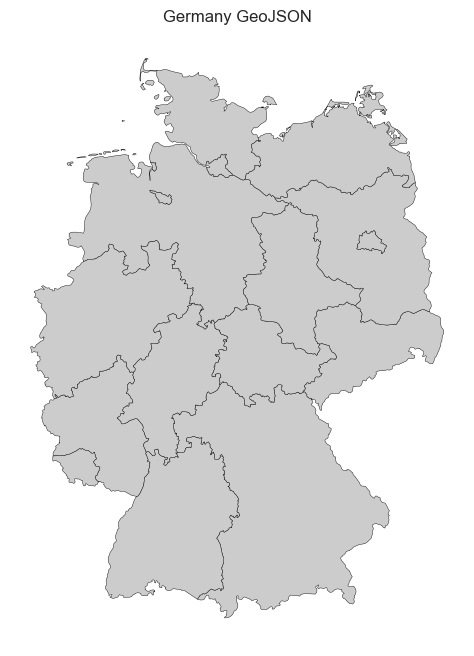

In [14]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely import wkt

hubs = pd.read_csv("KEP-hubs_v3.csv", sep=";")

# GeoJSON einlesen
gdf_de = gpd.read_file("de.json")

# CRS prüfen
print(gdf_de.crs)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
gdf_de.plot(ax=ax, color="#cccccc", edgecolor="black", linewidth=0.3)

ax.set_title("Germany GeoJSON")
ax.set_axis_off()
plt.show()

# Read the CSV file
folder = "input/"
areas = pd.read_csv( folder + "plz_areas.csv")  

# Convert the 'WKT' column to Shapely MultiPolygon geometry
areas['geometry'] = areas['WKT'].apply(lambda wkt_str: wkt.loads(wkt_str))

# Create a GeoDataFrame
gdf_areas = gpd.GeoDataFrame(areas, geometry='geometry')

# Set the coordinate reference system (CRS)
gdf_areas.crs = 'EPSG:25832'  # Set the appropriate CRS if it's different


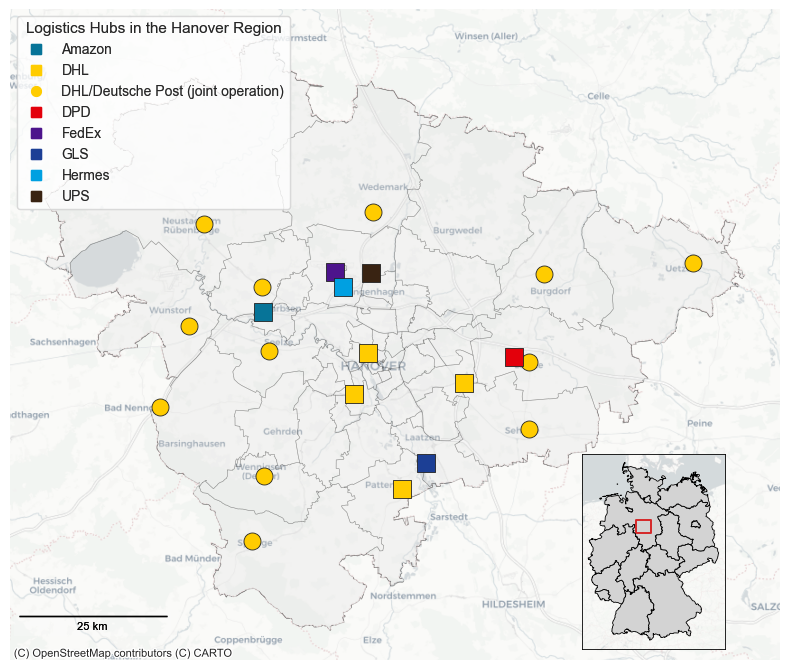

In [15]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import contextily as ctx
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from matplotlib.font_manager import FontProperties
import matplotlib.patches as mpatches


def add_fixed_scalebar(ax, length_km=25, location='lower left', height_offset=0.1):
    """Add a fixed-length scalebar in meters (Web Mercator)."""
    size_m = float(length_km) * 1000.0
    label = f"{length_km:g} km"
    fp = FontProperties(size=8, weight='regular')
    scalebar = AnchoredSizeBar(
        transform=ax.transData,
        size=size_m,
        label=label,
        loc=location,
        pad=0.4,
        borderpad=0.4,
        sep=4,
        frameon=False,
        color='black',
        fontproperties=fp,
        fill_bar=True,
        bbox_to_anchor=(0, height_offset),
        bbox_transform=ax.transAxes
    )
    ax.add_artist(scalebar)
    # light background for readability
    renderer = ax.figure.canvas.get_renderer()
    bbox = scalebar.get_tightbbox(renderer)
    rect = mpatches.Rectangle(
        (bbox.x0 / ax.figure.bbox.width, bbox.y0 / ax.figure.bbox.height),
        (bbox.width / ax.figure.bbox.width),
        (bbox.height / ax.figure.bbox.height),
        transform=ax.figure.transFigure,
        facecolor='white',
        alpha=0.2,
        zorder=scalebar.zorder - 1,
        linewidth=0,
    )
    ax.add_artist(rect)
    ax.add_artist(scalebar)

## Fixed provider colors
prov_colors = {
    "dhl":    "#FFCC00",
    "dp/dhl": "#FFCC00",
    "dpd":    "#E3000B",
    "gls":    "#1C3F95",
    "ups":    "#392312",
    "hermes": "#00A0E1",
    "amazon": "#077498",
    "fedex":  "#4D148C",
    "other":  "#7f7f7f"
}

# Marker mapping
prov_markers = {
    "dhl": "s",
    "dp/dhl": "o",
    "dpd": "s",
    "gls": "s",
    "ups": "s",
    "hermes": "s",
    "amazon": "s",
    "fedex": "s",
    "other": "s"
}

# Legend labels (English for TRB)
prov_labels = {
    "dhl": "DHL",
    "dp/dhl": "DHL/Deutsche Post (joint operation)",
    "dpd": "DPD",
    "gls": "GLS",
    "ups": "UPS",
    "hermes": "Hermes",
    "amazon": "Amazon",
    "fedex": "FedEx",
    "other": "Other"
}

# Normalize X Y if needed
if "# X" in hubs.columns and "# Y" in hubs.columns:
    hubs = hubs.rename(columns={"# X": "X", "# Y": "Y"})

# Build GeoDataFrame for hubs (assume EPSG:25832)
hub_geom = [Point(float(x), float(y)) for x, y in zip(hubs["X"], hubs["Y"])]
hubs_gdf = gpd.GeoDataFrame(hubs.copy(), geometry=hub_geom, crs="EPSG:25832")

# Ensure areas have CRS, then project both to Web Mercator for tiles
if gdf_areas.crs is None:
    gdf_areas = gdf_areas.set_crs(epsg=25832)
gdf_areas_3857 = gdf_areas.to_crs(epsg=3857)
hubs_gdf_3857 = hubs_gdf.to_crs(epsg=3857)

hubs_sorted = hubs_gdf_3857.sort_values(["Anbieter"]) 
hubs_sorted["hub_id"] = np.arange(1, len(hubs_sorted) + 1)

# Classify provider to keys
def provider_key(raw: str) -> str:
    s = str(raw).strip().lower()
    if "dp/dhl" in s or s.startswith("dp ") or s == "dp" or "deutsche post" in s:
        return "dp/dhl"
    if "dhl" in s or "wl" in s:
        return "dhl"
    if "dpd" in s:
        return "dpd"
    if "gls" in s:
        return "gls"
    if "ups" in s:
        return "ups"
    if "hermes" in s:
        return "hermes"
    if "amazon" in s:
        return "amazon"
    if "fedex" in s:
        return "fedex"
    return "other"

hubs_sorted["prov_key"] = hubs_sorted["Anbieter"].apply(provider_key)

# Plot main map
fig, ax = plt.subplots(figsize=(8, 8))

gdf_areas_3857.plot(
    ax=ax,
    color="#dddddd",
    alpha=0.25,
    edgecolor="black",
    linewidth=0.4,
    zorder=1
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    crs=gdf_areas_3857.crs.to_string(),
    attribution_size=8,
    zorder=0
)

present_keys = list(np.unique(hubs_sorted["prov_key"]))
for k in present_keys:
    sub = hubs_sorted[hubs_sorted["prov_key"] == k]
    ax.scatter(
        sub.geometry.x, sub.geometry.y,
        marker=prov_markers.get(k, "o"),
        facecolor=prov_colors.get(k, prov_colors["other"]),
        edgecolor="#222222",
        linewidth=0.6,
        s=150,
        zorder=3,
        label=prov_labels.get(k, k)
    )
    
# import matplotlib.patheffects as pe
# for _, r in hubs_sorted.iterrows():
#     provider = r["prov_key"]
#     fontcolor = "black" if provider in ["dhl", "dp/dhl"] else "white"

#     ax.text(
#         r.geometry.x, r.geometry.y,
#         str(int(r["hub_id"])),
#         fontsize=8,
#         ha="center", va="center",
#         zorder=4,
#         color=fontcolor
#     )

handles = [
    mlines.Line2D([], [], color=prov_colors.get(k, prov_colors["other"]),
                  marker=prov_markers.get(k, "o"),
                  linestyle="", markersize=7)
    for k in present_keys
]
labels = [prov_labels.get(k, k) for k in present_keys]
leg = ax.legend(handles, labels, title="Logistics Hubs in the Hanover Region",
                loc="upper left", frameon=True, framealpha=0.5, fontsize=10, title_fontsize=11)
ax.add_artist(leg)


ax.get_yaxis().set_visible(False)
ax.get_xaxis().set_visible(False)
for s in ["left", "bottom", "right", "top"]:
    ax.spines[s].set_visible(False)

ax.set_aspect("equal", adjustable="box")
plt.tight_layout()

# -------- Inset map of Germany using your existing 'germany' --------
# Ensure CRS and project to 3857
if gdf_de.crs is None:
    # set to your known source CRS if needed, else assume WGS84
    gdf_de = gdf_de.set_crs(epsg=4326)
gdf_de_3857 = gdf_de.to_crs(epsg=3857)

# Region bbox from main map
minx, miny, maxx, maxy = gdf_areas_3857.total_bounds
region_rect = gpd.GeoDataFrame({"geometry": [box(minx, miny, maxx, maxy)]}, crs=gdf_areas_3857.crs)

# Inset axes
ax_in = inset_axes(ax, width="30%", height="30%", loc="lower right", borderpad=0.8)

# Germany outline
gdf_de_3857.plot(ax=ax_in,  facecolor="lightgray", edgecolor="black", linewidth=0.6, zorder=1)

# Basemap without labels for clarity
try:
    ctx.add_basemap(
        ax_in,
        source=ctx.providers.CartoDB.PositronNoLabels,
        crs=gdf_de_3857.crs.to_string(),
        attribution=False,
        zorder=0
    )
except Exception:
    pass

# Draw region bbox
region_rect.boundary.plot(ax=ax_in, edgecolor="#d62728", linewidth=1.4, zorder=2)

# Fit inset to Germany extent with small padding
gxmin, gymin, gxmax, gymax = gdf_de_3857.total_bounds
padx = (gxmax - gxmin) * 0.05
pady = (gymax - gymin) * 0.05
ax_in.set_xlim(gxmin - padx, gxmax + padx)
ax_in.set_ylim(gymin - pady, gymax + pady)

# Inset styling
ax_in.set_xticks([])
ax_in.set_yticks([])
for s in ["left", "bottom", "right", "top"]:
    ax_in.spines[s].set_visible(True)
    ax_in.spines[s].set_linewidth(0.6)
    ax_in.spines[s].set_edgecolor("black")
    

add_fixed_scalebar(ax, length_km=25, location='lower left', height_offset=0.03)
        
fig.savefig("logistics_hubs_mobiltum.pdf", format="pdf", bbox_inches="tight", pad_inches=0.02, transparent=True)

plt.show()

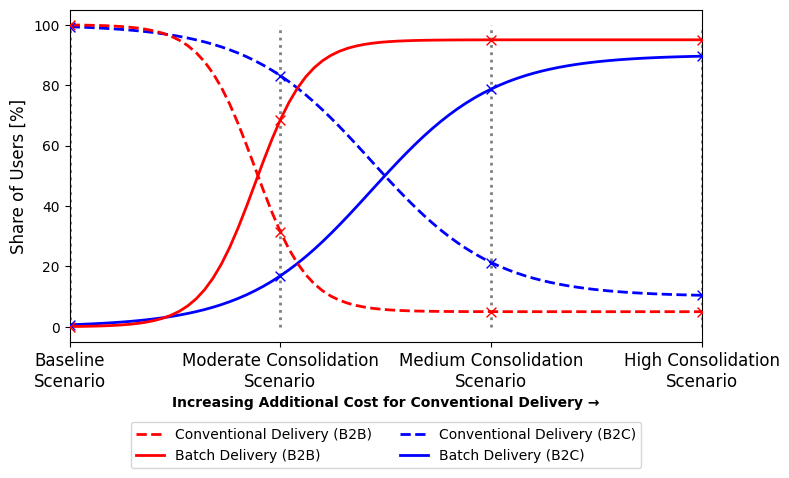

In [ ]:
# Jetzt: Vertikale Linien = Szenariofarbe | Kreuze = Linienfarbe (B2B/Neutral/B2C)
import numpy as np
import matplotlib.pyplot as plt

# Preisachse
price = np.linspace(1, 10, 100)

# Preis minimal verschieben für Modellierung
price_shifted = price - 1.25

# B2C-Modell
fast_delivery_b2c = 10 + (90) / (1 + np.exp(1.5 * (price_shifted - 3)))
batch_delivery_b2c = 100 - fast_delivery_b2c

# B2B-Modell
fast_delivery_b2b = 5 + (95) / (1 + np.exp(3.5 * (price_shifted - 1.75)))
batch_delivery_b2b = 100 - fast_delivery_b2b

# Cost levels
cost_levels = [0.0, 0.25, 0.5, 0.75]  # Nur vier Punkte

sample_prices = [price[int(len(price) * c)] for c in cost_levels]

scenario_labels = [
    "Baseline\nScenario",
    "Moderate Consolidation\nScenario",
    "Medium Consolidation\nScenario",
    "High Consolidation\nScenario"
 ]

# Scenario colors for vertical lines
scenario_colors = ["black", "blue", "red", "red", "purple"]

# Curve colors for crosses
curve_colors = {
    "fast_b2c": "blue",
    "batch_b2c": "blue",
    "fast_neutral": "green",
    "batch_neutral": "green",
    "fast_b2b": "red",
    "batch_b2b": "red"
}

# Create the plot
plt.figure(figsize=(8,5 ))

# Plot curves with updated legend labels
plt.plot(price, fast_delivery_b2c, linestyle="--", color="blue", linewidth=2, label="Conventional Delivery (B2C)")
plt.plot(price, batch_delivery_b2c, linestyle="-", color="blue", linewidth=2, label="Batch Delivery (B2C)")

# plt.plot(price, fast_delivery_neutral, linestyle="--", color="green", linewidth=2, label="Fast Delivery (Neutral)")
# plt.plot(price, batch_delivery_neutral, linestyle="-", color="green", linewidth=2, label="Batch Delivery (Neutral)")

plt.plot(price, fast_delivery_b2b, linestyle="--", color="red", linewidth=2, label="Conventional Delivery (B2B)")
plt.plot(price, batch_delivery_b2b, linestyle="-", color="red", linewidth=2, label="Batch Delivery (B2B)")

# Add vertical lines and crosses at intersections
for i, p in enumerate(sample_prices):
    scenario_color = scenario_colors[i]
    
    # Vertical line from 0 to 100 in scenario color
    plt.plot([p, p], [0, 100], color="gray", linestyle="dotted", linewidth=2, zorder=1)
    
    # Find closest index
    idx = np.argmin(np.abs(price - p))
    
    # Plot crosses in curve color
    plt.scatter(p, fast_delivery_b2c[idx], color=curve_colors["fast_b2c"], marker='x', s=50, linewidths=1, zorder=3)
    plt.scatter(p, batch_delivery_b2c[idx], color=curve_colors["batch_b2c"], marker='x', s=50, linewidths=1, zorder=3)
    
    plt.scatter(p, fast_delivery_b2b[idx], color=curve_colors["fast_b2b"], marker='x', s=50, linewidths=1, zorder=3)
    plt.scatter(p, batch_delivery_b2b[idx], color=curve_colors["batch_b2b"], marker='x', s=50, linewidths=1, zorder=3)

# Style settings
plt.xlabel("Increasing Additional Cost for Conventional Delivery →", fontsize=10, fontweight='bold')
plt.xticks(sample_prices, scenario_labels, rotation=0, ha="center", fontsize=12)

plt.ylabel("Share of Users [%]", fontsize=12)
# plt.title("Preferences Shift between fast and standard delivery at different cost levels for B2B and B2C parcel delivieries", pad=20)
# plt.xticks([])
plt.ylim(-5, 105)
plt.grid(False)

plt.xlim(1, 7.82)  # weil price von 1 bis 10 geht

# Legend (manuell sortiert)
handles, labels = plt.gca().get_legend_handles_labels()
label_handle_dict = dict(zip(labels, handles))

desired_order = [
    "Conventional Delivery (B2B)",
    "Batch Delivery (B2B)",
    "Conventional Delivery (B2C)",
    "Batch Delivery (B2C)"
 ]

sorted_handles = [label_handle_dict[label] for label in desired_order]
sorted_labels = desired_order

plt.legend(sorted_handles, sorted_labels, loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2, frameon=True, fontsize=10)

plt.tight_layout()
plt.savefig("preference_shift_b2b_b2c.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Deliveries per scenario and weekday: heatmap + lollipop vs baseline (fixed order/colors)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_style("white")

# Fixed scenario column name
scenario_col = "scenario"
if scenario_col not in df.columns:
    raise KeyError(f"Expected column '{scenario_col}' in df")

# Resolve day and delivery columns flexibly
day_candidates = ["weekday", "Weekday", "day", "Day"]
delivery_candidates = ["deliveries", "Deliveries", "total_deliveries", "Total", "total"]

day_col = next((c for c in day_candidates if c in df.columns), None)
delivery_col = next((c for c in delivery_candidates if c in df.columns), None)

if day_col is None:
    raise KeyError(f"No weekday column found in df; expected one of {day_candidates}")
if delivery_col is None:
    raise KeyError(f"No deliveries column found in df; expected one of {delivery_candidates}")

# German weekday order and mapping to English short labels
german_day_order = ["Montag", "Dienstag", "Mittwoch", "Donnerstag", "Freitag", "Samstag"]
german_to_short = {
    "Montag": "Mon", "Dienstag": "Tue", "Mittwoch": "Wed",
    "Donnerstag": "Thu", "Freitag": "Fri", "Samstag": "Sat", "Sonntag": "Sun"
}
english_day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
english_to_short = {
    "Monday": "Mon", "Tuesday": "Tue", "Wednesday": "Wed",
    "Thursday": "Thu", "Friday": "Fri", "Saturday": "Sat", "Sunday": "Sun"
}

# Detect what's in the data
day_norm = df[day_col].astype(str).str.strip()
present_days = day_norm.dropna().unique().tolist()

# Check if data has German weekdays
if any(d in german_day_order for d in present_days):
    # Use German order for aggregation, map to English short for display
    day_order = [d for d in german_day_order if d in present_days]
    day_labels = [german_to_short.get(d, d) for d in day_order]
elif any(d in english_day_order for d in present_days):
    day_order = [d for d in english_day_order if d in present_days]
    day_labels = [english_to_short.get(d, d) for d in day_order]
else:
    # fallback: use short names or whatever is present
    short_days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    day_order = [d for d in short_days if d in present_days] + [d for d in present_days if d not in short_days]
    day_labels = day_order

# Canonical order and colors
canonical_order = ["Baseline", "Moderate Consolidation", "Medium Consolidation", "High Consolidation"]
color_map = {
    "Baseline": "#808080",
    "Moderate Consolidation": "#1f77b4",  # blue
    "Medium Consolidation": "#2ca02c",    # green
    "High Consolidation": "#9467bd",      # purple
}

# Map actual scenario names to canonical display
def canonical_name(name: str) -> str:
    n = str(name).strip().lower()
    if "base" in n or n == "baseline":
        return "Baseline"
    if "moderate" in n:
        return "Moderate Consolidation"
    if "medium" in n:
        return "Medium Consolidation"
    if "high" in n:
        return "High Consolidation"
    return str(name)

actual_scens = df[scenario_col].dropna().astype(str).unique().tolist()
display_name = {s: canonical_name(s) for s in actual_scens}

# Build ordered list of actual scenario keys following canonical order
scenario_order = [
    s for canon in canonical_order
    for s in actual_scens
    if display_name[s] == canon
]
if not scenario_order:
    scenario_order = sorted(actual_scens)

# Pick baseline actual (first that maps to Baseline, else first)
baseline_candidates = [s for s in scenario_order if display_name[s] == "Baseline"]
BASELINE_SCENARIO = baseline_candidates[0] if baseline_candidates else scenario_order[0]

# Colors per actual scenario using canonical name
palette = sns.color_palette("Set1", len(scenario_order))
colors = {s: color_map.get(display_name[s], palette[i % len(palette)]) for i, s in enumerate(scenario_order)}

# Aggregate deliveries
df_day_total = (
    df.assign(
        Day=pd.Categorical(day_norm, categories=day_order, ordered=True),
        Scenario=pd.Categorical(df[scenario_col], categories=scenario_order, ordered=True),
        Total=pd.to_numeric(df[delivery_col], errors="coerce"),
    )
    .groupby(["Scenario", "Day"], as_index=False)["Total"].sum()
 )

base = (
    df_day_total[df_day_total["Scenario"] == BASELINE_SCENARIO]
    .set_index("Day")["Total"]
    .astype(float)
)

df_rel = df_day_total[df_day_total["Scenario"] != BASELINE_SCENARIO].copy()
df_rel["Baseline"] = pd.to_numeric(df_rel["Day"].map(base), errors="coerce")
df_rel["Total"] = pd.to_numeric(df_rel["Total"], errors="coerce")
den = df_rel["Baseline"].replace(0, np.nan)
df_rel["Diff_%"] = (df_rel["Total"] / den - 1.0) * 100.0

# Heatmap pivot
pivot_abs = (
    df_day_total.pivot(index="Scenario", columns="Day", values="Total")
    .reindex(index=scenario_order, columns=day_order)
)

# Lollipop settings
scens = [s for s in scenario_order if s != BASELINE_SCENARIO]
x_idx = np.arange(len(day_order))
offsets = np.linspace(-0.15, 0.15, num=len(scens)) if len(scens) > 0 else [0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7.2), gridspec_kw={"height_ratios": [1, 1.2]})

# Heatmap
im = ax1.imshow(pivot_abs.values, aspect="auto", cmap="Reds")
ax1.set_yticks(np.arange(len(pivot_abs.index)))
heatmap_labels = [display_name[s].replace(" Consolidation", "\nConsolidation") for s in pivot_abs.index]
ax1.set_yticklabels(heatmap_labels)
ax1.set_xticks(np.arange(len(pivot_abs.columns)))
ax1.set_xticklabels(day_labels)

vmax = np.nanmax(pivot_abs.values) if np.isfinite(pivot_abs.values).any() else 0
for i in range(pivot_abs.shape[0]):
    for j in range(pivot_abs.shape[1]):
        val = pivot_abs.values[i, j]
        ax1.text(
            j, i, f"{val:,.0f}", ha="center", va="center", fontsize=11,
            color="white" if vmax and val > 0.65 * vmax else "black"
        )

# ax1.set_title("Total deliveries per scenario and weekday", fontsize=11, fontweight="bold", pad=6)

# Lollipop (% vs baseline)
for k, scen in enumerate(scens):
    yvals = (
        df_rel.loc[df_rel["Scenario"] == scen]
        .set_index("Day").reindex(day_order)["Diff_%"].values
    )
    x_pos = x_idx + offsets[k]
    for xp, val in zip(x_pos, yvals):
        ax2.vlines(xp, 0, val, linewidth=2, color=colors[scen])
    ax2.plot(x_pos, yvals, "o", markersize=6, color=colors[scen], label=display_name[scen])

ax2.axhline(0, color="black", linestyle="--", linewidth=1)
ax2.set_xticks(x_idx)
ax2.set_xticklabels(day_labels)
ax2.set_ylabel("Difference vs Baseline [%]", fontsize=11)
ax2.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
# Opaque legend handles
legend_handles = [
    plt.Line2D([0], [0], marker="o", color=colors[s], lw=2, markersize=6, label=display_name[s], alpha=1.0)
    for s in scens
]
ax2.legend(handles=legend_handles, frameon=True, loc="lower center", bbox_to_anchor=(0.5, -0.2), ncol=max(1, len(scens)))

plt.tight_layout()
plt.savefig("daily_deliveries_scenario_weekday.pdf", dpi=300, bbox_inches="tight")
plt.show()

ModuleNotFoundError: No module named 'seaborn'

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_39664\1645721963.py:132: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dat.groupby("weekday", dropna=False)[[x_col, y_col]]


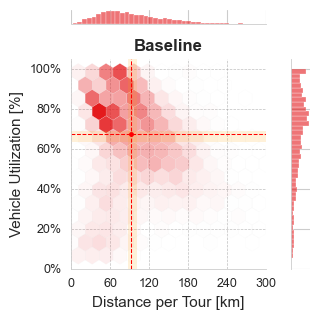

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_39664\1645721963.py:132: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dat.groupby("weekday", dropna=False)[[x_col, y_col]]


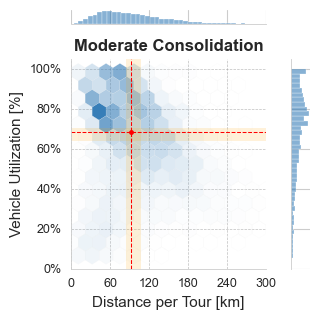

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_39664\1645721963.py:132: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dat.groupby("weekday", dropna=False)[[x_col, y_col]]


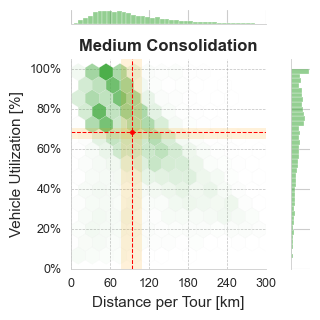

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_39664\1645721963.py:132: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dat.groupby("weekday", dropna=False)[[x_col, y_col]]


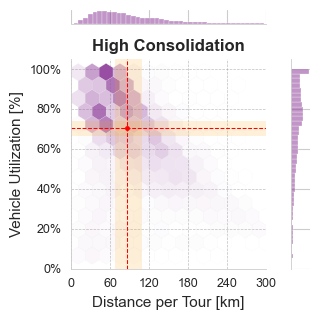

In [57]:
# =============================================================================
# HEX PLOTS PER SCENARIO (Batch analysis) — using Seaborn Set1 palette
# =============================================================================
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter
from datetime import datetime

sns.set_style("whitegrid")

# ---------------------------------------------------------------------
# 1) Prepare scenario and weekday columns
# ---------------------------------------------------------------------
weekday_order = ["Montag","Dienstag","Mittwoch","Donnerstag","Freitag","Samstag"]
weekday_map_en_de = {
    "Monday": "Montag", "Tuesday": "Dienstag", "Wednesday": "Mittwoch",
    "Thursday": "Donnerstag", "Friday": "Freitag", "Saturday": "Samstag", "Sunday": "Sonntag"
}

def _weekday_from_runname(run_name):
    m = re.search(r"_(\d{8})_", str(run_name))
    if not m:
        return None
    try:
        dt = datetime.strptime(m.group(1), "%d%m%Y")
        return weekday_map_en_de.get(dt.strftime("%A"), None)
    except Exception:
        return None

work = df_all.copy()

if "scenario" not in work.columns:
    if "run_name" not in work.columns:
        raise RuntimeError("run_name missing; cannot derive scenario")
    work["scenario"] = work["run_name"].astype(str).str.split("_").str[0]

if "weekday" not in work.columns:
    if "run_name" not in work.columns:
        raise RuntimeError("run_name missing; cannot derive weekday")
    work["weekday"] = work["run_name"].apply(_weekday_from_runname)
else:
    # Normalize existing weekday values to German if needed
    work["weekday"] = work["weekday"].astype(str).str.strip().replace(weekday_map_en_de)

# Mapping internal -> display names
scenario_display = {
    "basecase": "Baseline",
    "batchmoderate": "Moderate Consolidation",
    "batchmedium": "Medium Consolidation",
    "batchhigh": "High Consolidation",
}
work["scenario_label"] = work["scenario"].map(scenario_display).fillna(work["scenario"])

scenario_order = ["Baseline", "Moderate Consolidation", "Medium Consolidation", "High Consolidation"]
present_labels = [s for s in scenario_order if s in work["scenario_label"].unique().tolist()]
if not present_labels:
    present_labels = sorted(work["scenario_label"].unique().tolist())

# ---------------------------------------------------------------------
# 2) Assign Seaborn Set1 colors
# ---------------------------------------------------------------------
palette = sns.color_palette("Set1", len(scenario_order))
colors = dict(zip(scenario_order, palette))  # {'Baseline': (r,g,b), ...}

# ---------------------------------------------------------------------
# 3) Prepare data and parameters
# ---------------------------------------------------------------------
x_col = "Distance per Tour (km)" if "Distance per Tour (km)" in work.columns else "Tour Length (km)"
y_col = "Vehicle Utilization (%)"
for c in [x_col, y_col]:
    if c not in work.columns:
        raise RuntimeError(f"Required column '{c}' not found.")
    work[c] = pd.to_numeric(work[c], errors="coerce")

# Axis range
x_min, x_max = 0.0, 300.0
x_lim = (x_min, x_max)

y_vals = work[y_col].dropna().values
if np.nanmax(y_vals) <= 1.5:  # fraction 0..1
    y_lim = (0.0, 1.05)
    def to_percent(v, _): return f"{int(round(100*v))}%"
else:  # 0..100
    y_lim = (0.0, 100.0)
    def to_percent(v, _): return f"{int(round(v))}%"
percent_formatter = FuncFormatter(to_percent)

gridsize = 14
bins_marginal = 40

# ---------------------------------------------------------------------
# 4) Create transparent colormap for each scenario color
#     null value fully transparent (alpha from 0.0 to 1.0)
# ---------------------------------------------------------------------
def create_transparent_cmap(rgb_tuple, n_shades=20, alpha_start=0.0, alpha_end=1.0):
    r, g, b = rgb_tuple
    alpha = np.linspace(alpha_start, alpha_end, int(n_shades))
    colors_rgba = np.column_stack([
        np.full(len(alpha), r),
        np.full(len(alpha), g),
        np.full(len(alpha), b),
        alpha
    ])
    return LinearSegmentedColormap.from_list("custom_cmap", colors_rgba)

cmaps = {label: create_transparent_cmap(colors[label], n_shades=20, alpha_start=0.0, alpha_end=1.0)
         for label in present_labels}

# ---------------------------------------------------------------------
# 5) Plot for each scenario label with weekday means
# ---------------------------------------------------------------------
for scen_label in present_labels:
    dat = work[work["scenario_label"] == scen_label].copy()
    dat = dat[(dat[x_col].notna()) & (dat[y_col].notna()) &
              (dat[x_col] >= x_lim[0]) & (dat[x_col] <= x_lim[1])]

    if dat.empty:
        print(f"[INFO] No data for scenario '{scen_label}', skipping.")
        continue

    # Compute overall means for the scenario
    mean_x = float(dat[x_col].mean())
    mean_y = float(dat[y_col].mean())

    # Compute weekday means for the scenario
    dat["weekday"] = pd.Categorical(dat["weekday"], categories=weekday_order, ordered=True)
    wk = (
        dat.groupby("weekday", dropna=False)[[x_col, y_col]]
        .mean()
        .reindex(weekday_order)
    )

    cmap = cmaps[scen_label]

    g = sns.jointplot(
        data=dat,
        x=x_col, y=y_col,
        kind="hex",
        cmap=cmap,
        marginal_kws=dict(
            bins=bins_marginal,
            fill=True,
            color=colors.get(scen_label, "#666666"),
            alpha=0.6,
            edgecolor="white",
            linewidth=0.2,
        ),
        gridsize=gridsize,
        joint_kws={
            "extent": (x_lim[0], x_lim[1], y_lim[0], y_lim[1]),
            "edgecolors": "whitesmoke",
            "linewidths": 0.1,
            "mincnt": 1
        }
    )

    g.fig.set_size_inches(3.3, 3.3)
    ax = g.ax_joint
    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    ax.yaxis.set_major_formatter(percent_formatter)

    # Compute min/max across weekdays (ignore NaNs)
    wk_valid = wk[[x_col, y_col]].dropna(how="all")
    x_min_band = float(np.nanmin(wk_valid[x_col].values)) if wk_valid[x_col].notna().any() else None
    x_max_band = float(np.nanmax(wk_valid[x_col].values)) if wk_valid[x_col].notna().any() else None
    y_min_band = float(np.nanmin(wk_valid[y_col].values)) if wk_valid[y_col].notna().any() else None
    y_max_band = float(np.nanmax(wk_valid[y_col].values)) if wk_valid[y_col].notna().any() else None

    # Draw transparent bands using the scenario color (light alpha)
    band_color = "orange"

    if x_min_band is not None and x_max_band is not None:
        if x_min_band == x_max_band:
            x_pad = max(1.0, 0.01 * (x_lim[1] - x_lim[0]))
            ax.axvspan(x_min_band - x_pad, x_max_band + x_pad, facecolor=band_color, alpha=0.15, edgecolor="none", zorder=1)
        elif x_min_band < x_max_band:
            ax.axvspan(x_min_band, x_max_band, facecolor=band_color, alpha=0.15, edgecolor="none", zorder=1)

    if y_min_band is not None and y_max_band is not None:
        if y_min_band == y_max_band:
            y_pad = max(1.0, 0.01 * (y_lim[1] - y_lim[0]))
            ax.axhspan(y_min_band - y_pad, y_max_band + y_pad, facecolor=band_color, alpha=0.15, edgecolor="none", zorder=1)
        elif y_min_band < y_max_band:
            ax.axhspan(y_min_band, y_max_band, facecolor=band_color, alpha=0.15, edgecolor="none", zorder=1)

    # Overall mean lines
    ax.axvline(mean_x, ls="--", lw=0.75, color="red")
    ax.axhline(mean_y, ls="--", lw=0.75, color="red")
    ax.plot(mean_x, mean_y, ".", markersize=5, color="red")

    # Ticks and labels
    ax.set_xticks(np.linspace(x_lim[0], x_lim[1], 6))
    ax.tick_params(axis="both", which="major", labelsize=9)
    g.set_axis_labels("Distance per Tour [km]", "Vehicle Utilization [%]", fontsize=11)
    ax.set_title(scen_label, fontsize=12, pad=6, weight="bold")
    ax.grid(True, linestyle="--", linewidth=0.5, color="gray", alpha=0.5)

    plt.tight_layout()
    fname = f"hex_{scen_label.replace(' ', '_').lower()}.pdf"
    plt.savefig(fname, format="pdf", dpi=300, bbox_inches="tight")
    plt.show()


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_61676\3358455679.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("weekday", dropna=False)[kpis]
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_61676\3358455679.py:202: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("weekday", dropna=False)[kpis]
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_61676\3358455679.py:202: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silen

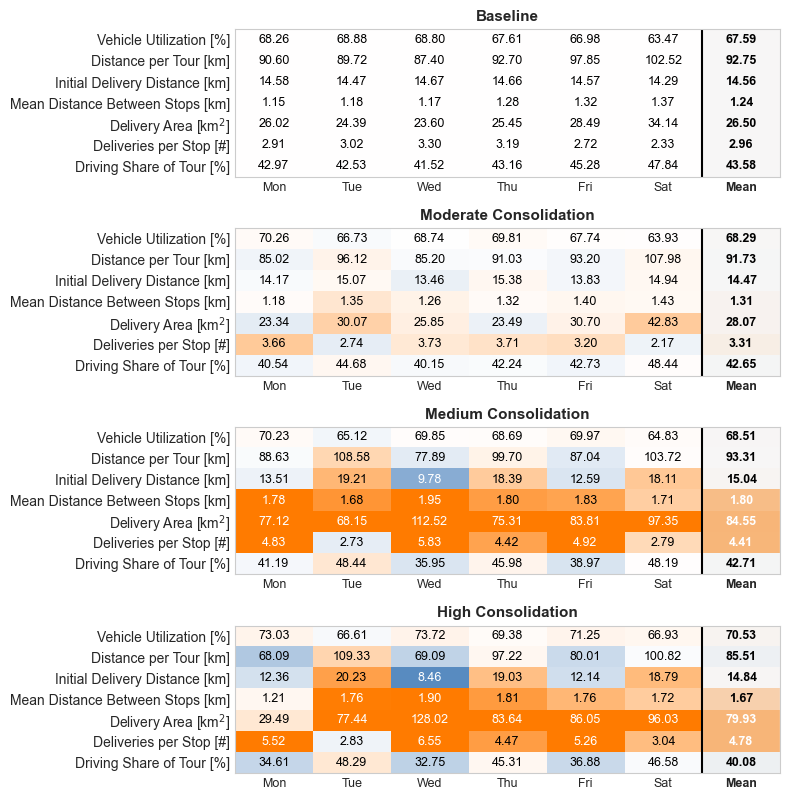

In [ ]:
# =============================================================================
# Build weekly KPI deltas directly from df_all and plot
# =============================================================================
import re
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm, to_rgba

# -----------------------------
# 0) Configuration
# -----------------------------
weekday_order  = ["Montag","Dienstag","Mittwoch","Donnerstag","Freitag","Samstag"]
weekday_labels = ["Mon","Tue","Wed","Thu","Fri","Sat"]
weekday_labels_with_avg = ["Mon","Tue","Wed","Thu","Fri","Sat","Mean"]

COLOR_NEG = "#2b6cb0"
COLOR_NEU = "#707070"
COLOR_POS = "#ff7b00"

NEUTRAL_BAND = 2.5
SIZE_CAP = 50.0  # cap for color normalization

# Canonical KPI list expected downstream
kpis_all = [
    "Vehicle Utilization (%)",
    "Distance per Tour (km)",
    "Initial Delivery Distance (km)",
    "Mean Distance Between Stops (km)",
    "Delivery Area (km^2)",
    "Deliveries per Stop",
    "Driving Share of Tour (%)",
]

# -----------------------------
# 1) Harmonize df_all
# -----------------------------
_df_src = df_all.copy()

_df_src["Vehicle Utilization (%)"] = _df_src["Vehicle Utilization (%)"] * 100

# Scenario from run_name prefix
if "scenario" not in _df_src.columns:
    if "run_name" not in _df_src.columns:
        raise RuntimeError("Column 'run_name' is missing in df_all.")
    _df_src["scenario"] = _df_src["run_name"].astype(str).str.split("_").str[0]

# Weekday: ensure German names for consistency with weekday_order
map_en_de = {
    "Monday": "Montag", "Tuesday": "Dienstag", "Wednesday": "Mittwoch",
    "Thursday": "Donnerstag", "Friday": "Freitag", "Saturday": "Samstag", "Sunday": "Sonntag"
}

if "weekday" not in _df_src.columns:
    def _weekday_from_runname(run_name):
        m = re.search(r"_(\d{8})_", str(run_name))
        if not m:
            return None
        try:
            dt = datetime.strptime(m.group(1), "%d%m%Y")
            return map_en_de.get(dt.strftime("%A"), None)
        except Exception:
            return None
    _df_src["weekday"] = _df_src["run_name"].apply(_weekday_from_runname)
else:
    # Map existing English weekday names to German
    _df_src["weekday"] = _df_src["weekday"].astype(str).str.strip().replace(map_en_de)

# Robust alias mapping: raw -> canonical
rename_to_canonical = {
    "Tour Length (km)": "Distance per Tour (km)",
    "delivery_area_km2": "Delivery Area (km^2)",
    "deliveries_per_stop": "Deliveries per Stop",
    "mean_dist_between_stops": "Mean Distance Between Stops (km)",
    "driving_share": "Driving Share of Tour (%)",
}
rename_actual = {raw: canon for raw, canon in rename_to_canonical.items() if raw in _df_src.columns}
_df_src.rename(columns=rename_actual, inplace=True)

# Determine available KPIs
kpis = [c for c in kpis_all if c in _df_src.columns]
if not kpis:
    raise RuntimeError("No KPI columns from the canonical list are present in df_all.")

# Ensure numeric KPIs
for c in kpis:
    _df_src[c] = pd.to_numeric(_df_src[c], errors="coerce")

# Ensure deliveries column is numeric
if "deliveries" in _df_src.columns:
    _df_src["deliveries"] = pd.to_numeric(_df_src["deliveries"], errors="coerce")

# -----------------------------
# 2) Aggregate to weekly means per scenario
#    average per run first if run_name exists
# -----------------------------
_group_dims = ["weekday", "scenario"]
if "run_name" in _df_src.columns:
    _per_run = _df_src.groupby(_group_dims + ["run_name"], dropna=False)[kpis].mean().reset_index()
    scen_weekly_abs = _per_run.groupby(_group_dims, dropna=False)[kpis].mean().reset_index()
    # Also aggregate total deliveries per weekday/scenario for weighted avg
    if "deliveries" in _df_src.columns:
        _del_per_run = _df_src.groupby(_group_dims + ["run_name"], dropna=False)["deliveries"].sum().reset_index()
        scen_weekly_deliveries = _del_per_run.groupby(_group_dims, dropna=False)["deliveries"].sum().reset_index()
    else:
        scen_weekly_deliveries = None
else:
    scen_weekly_abs = _df_src.groupby(_group_dims, dropna=False)[kpis].mean().reset_index()
    if "deliveries" in _df_src.columns:
        scen_weekly_deliveries = _df_src.groupby(_group_dims, dropna=False)["deliveries"].sum().reset_index()
    else:
        scen_weekly_deliveries = None

# Reindex weekdays to fixed order
scen_weekly_abs["weekday"] = pd.Categorical(
    scen_weekly_abs["weekday"], categories=weekday_order, ordered=True
)
scen_weekly_abs = (
    scen_weekly_abs
    .dropna(subset=["scenario"])
    .sort_values(["scenario", "weekday"])
    .reset_index(drop=True)
)

# -----------------------------
# 3) Detect baseline scenario
# -----------------------------
present_scens = sorted(scen_weekly_abs["scenario"].astype(str).unique().tolist())
_baseline = None
for key in ["basecase","baseline","base","bau","ref","reference","statusquo","status_quo","status-quo","basis","default"]:
    hit = [s for s in present_scens if key in s.lower()]
    if hit:
        _baseline = hit[0]
        break
_baseline = _baseline or present_scens[0]

# -----------------------------
# 4) Build percent deltas vs baseline
# -----------------------------
base_week = (
    scen_weekly_abs[scen_weekly_abs["scenario"] == _baseline]
    .groupby("weekday", dropna=False)[kpis]
    .mean()
    .reindex(weekday_order)
    .reset_index()
)

# -----------------------------
# 5) Plot weekly matrices
# -----------------------------

# Which KPIs should drive the coloring
color_kpis = [
    "Vehicle Utilization (%)",
    "Distance per Tour (km)",
    "Initial Delivery Distance (km)",
    "Mean Distance Between Stops (km)",
    "Delivery Area (km^2)",
    "Deliveries per Stop",
    "Driving Share of Tour (%)",
]
color_kpis = [c for c in color_kpis if c in kpis]

# Scenario order
scen_order_pref = ["basecase", "batchmoderate", "batchmedium", "batchhigh"]
scenarios_all = [s for s in scen_order_pref if s in present_scens] or present_scens

# Colormap: white at zero, blue for negative, orange for positive
COLOR_NEG = "#2b6cb0"
COLOR_NEU = "#ffffff"
COLOR_POS = "#ff7b00"
cmap = LinearSegmentedColormap.from_list("neg_white_pos", [COLOR_NEG, COLOR_NEU, COLOR_POS], N=256)
norm = TwoSlopeNorm(vmin=-SIZE_CAP, vcenter=0.0, vmax=SIZE_CAP)

def _text_color_for_bg(rgb_tuple):
    r, g, b, *_ = rgb_tuple if len(rgb_tuple) == 4 else (*rgb_tuple, 1.0)
    L = 0.2126*r + 0.7152*g + 0.0722*b
    return "black" if L > 0.6 else "white"

title_map = {
    "basecase": "Baseline",
    "batchmoderate": "Moderate Consolidation",
    "batchmedium": "Medium Consolidation",
    "batchhigh": "High Consolidation"
}

# Helper: get delivery weights for a scenario
def _get_delivery_weights(s):
    if scen_weekly_deliveries is None:
        return None
    sub_del = scen_weekly_deliveries[scen_weekly_deliveries["scenario"] == s].copy()
    sub_del["weekday"] = pd.Categorical(sub_del["weekday"], categories=weekday_order, ordered=True)
    sub_del = sub_del.sort_values("weekday").set_index("weekday").reindex(weekday_order)["deliveries"].values
    return np.nan_to_num(sub_del, nan=0.0)

# Helper: absolute matrix for a scenario s (with delivery-weighted weekly average column)
def _abs_matrix_for_scenario(s):
    sub_abs = scen_weekly_abs[scen_weekly_abs["scenario"] == s].copy()
    sub_abs = (
        sub_abs
        .groupby("weekday", dropna=False)[kpis]
        .mean()
        .reindex(weekday_order)
    )
    M = sub_abs[kpis].T.values  # rows=kpis, cols=weekdays
    
    # Compute delivery-weighted average if deliveries data available
    weights = _get_delivery_weights(s)
    if weights is not None and weights.sum() > 0:
        # Weighted average: sum(value * weight) / sum(weight)
        avg_col = np.nansum(M * weights, axis=1, keepdims=True) / weights.sum()
    else:
        avg_col = np.nanmean(M, axis=1, keepdims=True)
    return np.hstack([M, avg_col])

# Helper: percent delta matrix vs baseline for a scenario s (with delivery-weighted weekly average column)
def _pct_matrix_vs_base(s):
    n_cols = len(weekday_order) + 1  # +1 for avg column
    if s == _baseline:
        return np.zeros((len(kpis), n_cols), dtype=float)
    sub = scen_weekly_abs[scen_weekly_abs["scenario"] == s].copy()
    sub = (
        sub
        .groupby("weekday", dropna=False)[kpis]
        .mean()
        .reset_index()
        .merge(
            base_week[["weekday"] + kpis],
            on="weekday", how="left", suffixes=("", "__base")
        )
        .set_index("weekday")
        .reindex(weekday_order)
        .reset_index()
    )
    M = np.empty((len(kpis), len(weekday_order)), dtype=float)
    for r, k in enumerate(kpis):
        num = pd.to_numeric(sub[k], errors="coerce").to_numpy()
        den = pd.to_numeric(sub[f"{k}__base"], errors="coerce").to_numpy()
        with np.errstate(divide="ignore", invalid="ignore"):
            d = (num / den - 1.0) * 100.0
        M[r, :] = d
    
    # Compute delivery-weighted average for delta if deliveries data available
    weights = _get_delivery_weights(s)
    if weights is not None and weights.sum() > 0:
        avg_col = np.nansum(M * weights, axis=1, keepdims=True) / weights.sum()
    else:
        avg_col = np.nanmean(M, axis=1, keepdims=True)
    return np.hstack([M, avg_col])

# KPI label formatting
def format_kpi_label(name: str) -> str:
    if not isinstance(name, str):
        return str(name)
    canon = {
        "Vehicle Utilization (%)": "Vehicle Utilization [%]",
        "Distance per Tour (km)": "Distance per Tour [km]",
        "Initial Delivery Distance (km)": "Initial Delivery Distance [km]",
        "Mean Distance Between Stops (km)": "Mean Distance Between Stops [km]",
        "Delivery Area (km^2)": "Delivery Area [km$^2$]",
        "Deliveries per Stop": "Deliveries per Stop [#]",
        "Driving Share of Tour (%)": "Driving Share of Tour [%]",
    }
    if name in canon:
        return canon[name]
    m = re.match(r"^(.*)\(([^)]+)\)\s*$", name.strip())
    if m:
        base = m.group(1).strip()
        unit = m.group(2).strip().replace("km²", "km^2")
        return f"{base} [{unit}]"
    return name

n_scen = len(scenarios_all)
n_cols = len(weekday_order) + 1  # 6 weekdays + 1 avg column

fig, axes = plt.subplots(n_scen, 1, figsize=(8.0, 2.5 + 0.2*len(kpis)*n_scen), squeeze=False)

# Precompute row indices of KPIs that should be colored
kpi_row_index = {k: i for i, k in enumerate(kpis)}
color_rows = [kpi_row_index[k] for k in color_kpis]

for i, scen in enumerate(scenarios_all):
    ax = axes[i, 0]

    # Absolute values to display as text
    M_abs = _abs_matrix_for_scenario(scen)

    # Delta matrix for coloring
    M_pct = _pct_matrix_vs_base(scen)

    # Build color driver matrix D: only selected KPI rows carry deltas, others are zero
    D = np.zeros_like(M_pct)
    if scen != _baseline and len(color_rows) > 0:
        D[color_rows, :] = M_pct[color_rows, :]

    # Draw background: baseline gets white; others use delta-based colors
    if scen == _baseline:
        im = ax.imshow(np.zeros_like(D), cmap=cmap, norm=norm, aspect="auto")
        im.set_alpha(1.0)
    else:
        im = ax.imshow(D, cmap=cmap, norm=norm, aspect="auto")
        A = 0.5 + 0.5 * np.clip(np.abs(np.nan_to_num(D, nan=0.0)) / SIZE_CAP, 0.0, 1.0)
        mask_noncolor = np.ones_like(D, dtype=bool)
        if len(color_rows) > 0:
            mask_noncolor[color_rows, :] = False
        A[mask_noncolor] = 0.0
        im.set_alpha(A)

    # Axes: 7 columns (6 weekdays + avg)
    ax.set_xticks(np.arange(n_cols))
    ax.set_xticklabels(weekday_labels_with_avg, fontsize=9)
    ax.set_yticks(np.arange(len(kpis)))
    ax.set_yticklabels([format_kpi_label(k) for k in kpis], fontsize=10)

    # Make "Avg" label bold
    xtick_labels = ax.get_xticklabels()
    xtick_labels[-1].set_fontweight("bold")

    # Title
    ax.set_title(title_map.get(scen, scen), fontsize=11, weight="bold", pad=6)

    # Cell annotations: absolute values
    for r in range(M_abs.shape[0]):
        for c in range(M_abs.shape[1]):
            val = M_abs[r, c]
            txt = "" if np.isnan(val) else f"{val:.2f}"
            # Text color based on background
            if scen == _baseline:
                tc = "black"
            else:
                bg_val = D[r, c]
                tc = _text_color_for_bg(to_rgba(cmap(norm(np.clip(np.nan_to_num(bg_val, nan=0.0), -SIZE_CAP, SIZE_CAP)))))
            # Make Avg column values bold
            fw = "bold" if c == n_cols - 1 else "normal"
            ax.text(c, r, txt, ha="center", va="center", fontsize=9, color=tc, fontweight=fw)

    # Clean look: no grid
    ax.grid(False)
    ax.tick_params(which="both", length=0)

    # Vertical line to separate Avg column
    ax.axvline(x=len(weekday_order) - 0.5, color="black", linewidth=1.5, linestyle="-")

    # Light gray background for Avg column
    ax.axvspan(len(weekday_order) - 0.5, n_cols - 0.5, facecolor="#f0f0f0", alpha=0.5, zorder=0)

plt.tight_layout()
fig.savefig("weekly_kpi_baseline_plus_deltas_from_df_all.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# =============================================================================
# Weighted scenario averages (deliveries-weighted, weekday-level like heatmap)
# =============================================================================
import numpy as np
import pandas as pd
import re
from datetime import datetime

# Work on copy
_dfw = df_all.copy()

# Ensure scenario column
if "scenario" not in _dfw.columns:
    if "run_name" not in _dfw.columns:
        raise RuntimeError("Column 'run_name' is missing in df_all.")
    _dfw["scenario"] = _dfw["run_name"].astype(str).str.split("_").str[0]

# Normalize weekday to German (same as heatmap)
map_en_de = {
    "Monday": "Montag", "Tuesday": "Dienstag", "Wednesday": "Mittwoch",
    "Thursday": "Donnerstag", "Friday": "Freitag", "Saturday": "Samstag", "Sunday": "Sonntag"
}
if "weekday" not in _dfw.columns:
    def _weekday_from_runname(run_name):
        m = re.search(r"_(\d{8})_", str(run_name))
        if not m:
            return None
        try:
            dt = datetime.strptime(m.group(1), "%d%m%Y")
            return map_en_de.get(dt.strftime("%A"), None)
        except Exception:
            return None
    _dfw["weekday"] = _dfw["run_name"].apply(_weekday_from_runname)
else:
    _dfw["weekday"] = _dfw["weekday"].astype(str).str.strip().replace(map_en_de)

# Resolve deliveries column
_delivery_candidates = ["deliveries", "Deliveries", "total_deliveries", "Total", "total"]
_delivery_col = next((c for c in _delivery_candidates if c in _dfw.columns), None)
if _delivery_col is None:
    raise RuntimeError(f"No deliveries column found; expected one of {_delivery_candidates}.")
_dfw[_delivery_col] = pd.to_numeric(_dfw[_delivery_col], errors="coerce")

# Resolve KPI columns (robust mapping)
_kpi_map = {
    "Avg. Tour Distance per Vehicle [km]": [
        "Avg. Tour Distance per Vehicle [km]",
        "Avg Tour Distance per Vehicle [km]",
        "Distance per Tour (km)",
        "Tour Length (km)",
    ],
    "Avg. Tour Duration [h]": [
        "Avg. Tour Duration [h]",
        "Avg Tour Duration [h]",
        "Tour Duration [h]",
        "Tour Duration (hrs)",
        "tour_duration_h",
        "tour_duration_hours",
        "tour_duration",
    ],
    "Avg. Vehicle Utilization [%]": [
        "Avg. Vehicle Utilization [%]",
        "Vehicle Utilization (%)",
        "Vehicle Utilization [%]",
        "vehicle_utilization",
    ],
}

def _resolve_col(candidates):
    return next((c for c in candidates if c in _dfw.columns), None)

resolved_cols = {}
for label, candidates in _kpi_map.items():
    col = _resolve_col(candidates)
    if col is None:
        raise RuntimeError(f"Missing KPI column for '{label}'. Tried: {candidates}")
    resolved_cols[label] = col
    _dfw[col] = pd.to_numeric(_dfw[col], errors="coerce")

# Convert utilization to percent if given as fraction
util_col = resolved_cols["Avg. Vehicle Utilization [%]"]
if _dfw[util_col].dropna().max() <= 1.5:
    _dfw[util_col] = _dfw[util_col] * 100.0

# Scenario ordering
present_scens = _dfw["scenario"].astype(str).unique().tolist()

def _scenario_rank(s: str) -> int:
    s_low = str(s).lower()
    if "base" in s_low:
        return 0
    if "moderate" in s_low:
        return 1
    if "medium" in s_low:
        return 2
    if "high" in s_low:
        return 3
    return 99

scenario_order = sorted(present_scens, key=_scenario_rank)

# Weighted average per scenario (weekday-level weighting)
rows = []
for scen in scenario_order:
    sub = _dfw[_dfw["scenario"] == scen].copy()
    # deliveries per weekday
    w_by_day = sub.groupby("weekday", dropna=False)[_delivery_col].sum()
    w_by_day = w_by_day.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    avg_vals = {"scenario": scen}
    for label, col in resolved_cols.items():
        v_by_day = sub.groupby("weekday", dropna=False)[col].mean()
        # align indexes
        aligned = v_by_day.reindex(w_by_day.index)
        w = w_by_day.values.astype(float)
        v = aligned.values.astype(float)
        if np.nansum(w) > 0:
            avg_vals[label] = np.nansum(v * w) / np.nansum(w)
        else:
            avg_vals[label] = np.nan
    rows.append(avg_vals)

weighted_avg_df = pd.DataFrame(rows)
weighted_avg_df = weighted_avg_df[["scenario"] + list(resolved_cols.keys())]

# Display results
weighted_avg_df

,scenario,Avg. Tour Distance per Vehicle [km],Avg. Tour Duration [h],Avg. Vehicle Utilization [%]
0,basecase,92.748210,7.647107,67.586616
1,batchmoderate,91.733783,7.641625,68.290921
2,batchmedium,93.311471,7.446221,68.510862
3,batchhigh,85.513984,7.367576,70.526127


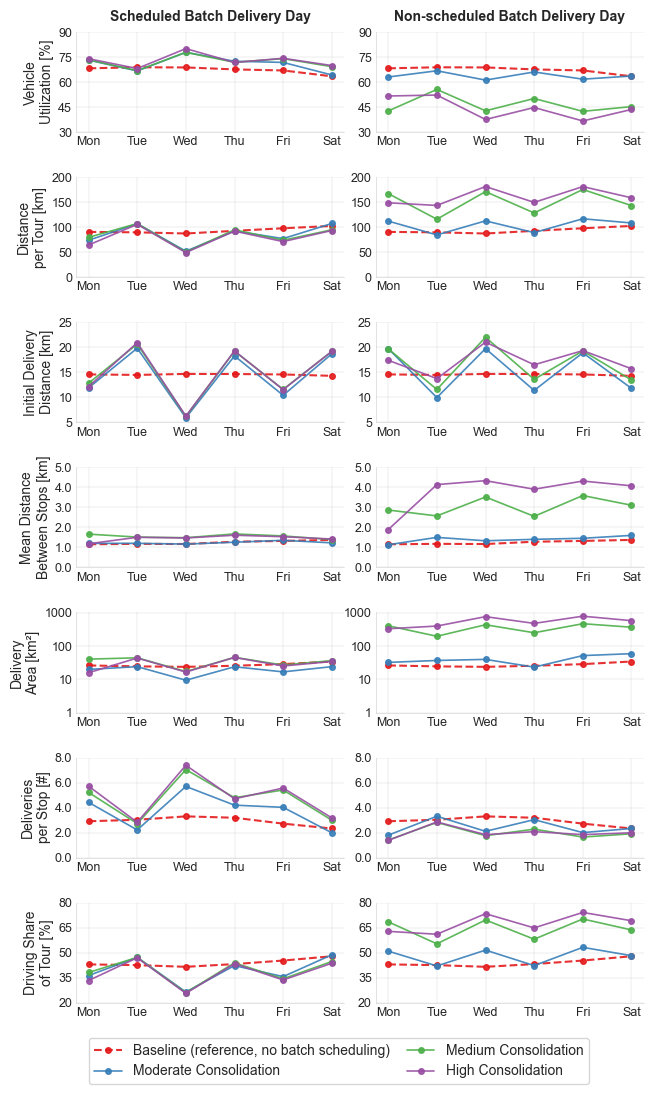

✓ Saved: TRB_KPI_weekly_comparison.pdf (7.09" × 11.0")
KPIs plotted: ['Vehicle Utilization (%)', 'Distance per Tour (km)', 'Initial Delivery Distance (km)', 'Mean Distance Between Stops (km)', 'Delivery Area (km^2)', 'Deliveries per Stop', 'Driving Share of Tour (%)']
Baseline: basecase (dashed line, same in both panels)
Batch scenarios: ['batchmoderate', 'batchmedium', 'batchhigh']


In [38]:
# =============================================================================
# Compact multi-panel layout for Springer journal
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D

# -----------------------------
# Springer Nature Publication Settings
# Double column width: 180mm = 7.09 inch
# -----------------------------
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'font.family': 'sans-serif',
    'axes.linewidth': 0.6,
    'lines.linewidth': 1.2,
    'lines.markersize': 4,
})

# Only batch scenarios for line plots (NOT baseline)
SCENARIOS_BATCH = [s for s in scenarios_plot if 'base' not in s.lower()] if "scenarios_plot" in globals() else None
BASELINE_SCENARIO = "basecase"  # Will be shown as dashed line

if "df" not in globals():
    raise RuntimeError("df not found.")
if "kpis" not in globals() or not kpis:
    raise RuntimeError("kpis list not found/empty.")

# Canonical weekday mapping
_weekday_idx = {
    "mon": 0, "monday": 0, "tue": 1, "tuesday": 1, "wed": 2, "wednesday": 2,
    "thu": 3, "thursday": 3, "fri": 4, "friday": 4, "sat": 5, "saturday": 5,
    "sun": 6, "sunday": 6, "mo": 0, "di": 1, "mi": 2, "do": 3, "fr": 4, "sa": 5, "so": 6,
}
_idx_to_label = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat"}

def canonical_weekday_idx(x):
    if x is None: return np.nan
    return _weekday_idx.get(str(x).strip().lower(), np.nan)

dline = df.copy()

# Provider column
if "provider" not in dline.columns:
    if "logisticProvider" in dline.columns:
        dline["provider"] = dline["logisticProvider"].astype(str)
    elif "carrierID" in dline.columns:
        dline["provider"] = dline["carrierID"].astype(str)
    else:
        raise RuntimeError("No provider column found.")
dline["provider"] = dline["provider"].astype(str).str.strip().str.lower()

# Scenario
if "scenario" in dline.columns:
    dline["scenario"] = dline["scenario"].astype(str)

# Normalize KPI column names (alias -> canonical)
rename_to_canonical = {
    "Tour Length (km)": "Distance per Tour (km)",
    "delivery_area_km2": "Delivery Area (km^2)",
    "deliveries_per_stop": "Deliveries per Stop",
}
rename_actual = {raw: canon for raw, canon in rename_to_canonical.items() if raw in dline.columns}
if rename_actual:
    dline.rename(columns=rename_actual, inplace=True)

# Scenarios
present_sc = dline["scenario"].unique().tolist()

# Find baseline scenario
baseline_str = None
for sc in present_sc:
    if 'base' in sc.lower():
        baseline_str = sc
        break

# Ordering for scenarios
scenario_order_pref = ["baseline", "moderate", "medium", "high"]

def _scenario_rank(s: str) -> int:
    s_low = str(s).lower()
    if "base" in s_low:
        return 0
    if "moderate" in s_low:
        return 1
    if "medium" in s_low:
        return 2
    if "high" in s_low:
        return 3
    return 99

# Set batch scenarios (excluding baseline) with stable order
if SCENARIOS_BATCH is None:
    SCENARIOS_BATCH = [s for s in sorted(present_sc, key=_scenario_rank) if 'base' not in s.lower()]
else:
    SCENARIOS_BATCH = [str(s) for s in SCENARIOS_BATCH if str(s) in present_sc and 'base' not in str(s).lower()]
    SCENARIOS_BATCH = sorted(SCENARIOS_BATCH, key=_scenario_rank)

# Weekdays
dline["weekday"] = dline["weekday"].astype(str)
dline["weekday_idx"] = dline["weekday"].map(canonical_weekday_idx)
dline = dline[dline["weekday_idx"].notna()].copy()
dline["weekday_idx"] = dline["weekday_idx"].astype(int)

if "weekday_order" in globals():
    _pref = [canonical_weekday_idx(w) for w in weekday_order]
    wd_order_idx = [int(i) for i in _pref if pd.notna(i)]
    present_idx = set(dline["weekday_idx"].unique().tolist())
    wd_order_idx = [i for i in wd_order_idx if i in present_idx] or sorted(present_idx)
else:
    wd_order_idx = sorted(dline["weekday_idx"].unique().tolist())

wd_labels = [_idx_to_label.get(i, str(i)) for i in wd_order_idx]

# Providers
if "provider_active_days" in globals() and isinstance(provider_active_days, dict):
    providers = [str(p).strip().lower() for p in provider_active_days.keys()]
    providers = [p for p in providers if p in set(dline["provider"].unique())]
else:
    providers = dline["provider"].unique().tolist()

# KPIs
kpis_present = [k for k in kpis if k in dline.columns]
for c in kpis_present:
    dline[c] = pd.to_numeric(dline[c], errors="coerce")

# =====================================================
# Unit conversions & Y-axis labels mapping
# =====================================================
UNIT_CONVERSIONS = {
    'vehicle_utilization': 100,
    'Vehicle Utilization (%)': 100,
}

ROW_LABELS = {
    'vehicle_utilization': 'Vehicle\nUtilization [%]',
    'Vehicle Utilization (%)': 'Vehicle\nUtilization [%]',
    'distance_per_tour': 'Distance\nper Tour [km]',
    'Distance per Tour (km)': 'Distance\nper Tour [km]',
    'initial_delivery_distance': 'Initial Delivery\nDistance [km]',
    'Initial Delivery Distance (km)': 'Initial Delivery\nDistance [km]',
    'mean_distance_between_stops': 'Mean Distance\nBetween Stops [km]',
    'Mean Distance Between Stops (km)': 'Mean Distance\nBetween Stops [km]',
    'delivery_area': 'Delivery\nArea [km²]',
    'Delivery Area (km^2)': 'Delivery\nArea [km²]',
    'deliveries_per_stop': 'Deliveries\nper Stop [#]',
    'Deliveries per Stop': 'Deliveries\nper Stop [#]',
    'driving_share': 'Driving Share\nof Tour [%]',
    'Driving Share of Tour (%)': 'Driving Share\nof Tour [%]',
}

# Apply unit conversions
for col, factor in UNIT_CONVERSIONS.items():
    if col in dline.columns:
        dline[col] = dline[col] * factor

# Provider active days
provider_active_days_idx = {
    str(p).strip().lower(): {int(canonical_weekday_idx(d)) for d in days if pd.notna(canonical_weekday_idx(d))}
    for p, days in provider_active_days.items()
}

# =====================================================
# Calculate BASELINE average per weekday (NO batch/non-batch distinction)
# =====================================================
baseline_data = dline[dline["scenario"] == baseline_str].copy() if baseline_str else pd.DataFrame()
baseline_avg_per_day = {}
if not baseline_data.empty:
    baseline_agg = baseline_data.groupby("weekday_idx")[kpis_present].mean()
    for kpi in kpis_present:
        baseline_avg_per_day[kpi] = baseline_agg[kpi].to_dict()

# =====================================================
# Filter for BATCH scenarios only & set batch flag
# =====================================================
mask = dline["scenario"].isin(SCENARIOS_BATCH) & dline["provider"].isin(providers)
dline_batch = dline[mask].copy()
dline_batch["is_batch"] = dline_batch.apply(
    lambda r: r["weekday_idx"] in provider_active_days_idx.get(r["provider"], set()), axis=1
)

# Aggregate KPIs for batch scenarios
grp_cols = ["scenario", "weekday_idx", "is_batch"]
if "run_name" in dline_batch.columns:
    per_run = dline_batch.groupby(grp_cols + ["run_name"], dropna=False, observed=False)[kpis_present].mean().reset_index()
    avg_data = per_run.groupby(grp_cols, dropna=False, observed=False)[kpis_present].mean().reset_index()
else:
    avg_data = dline_batch.groupby(grp_cols, dropna=False, observed=False)[kpis_present].mean().reset_index()

xpos = np.arange(len(wd_order_idx))
wd_idx_to_xpos = {idx: pos for pos, idx in enumerate(wd_order_idx)}

# ---------------------------------------------------------------------
# Assign Seaborn Set1 colors
# ---------------------------------------------------------------------
import seaborn as sns
scenario_order = ["Baseline", "Moderate Consolidation", "Medium Consolidation", "High Consolidation"]
palette = sns.color_palette("Set1", len(scenario_order))
colors = dict(zip(scenario_order, palette))

scen_labels = {
    'basecase': 'Baseline (no batching)',
    'batchmoderate': 'Moderate Consolidation',
    'batchmedium': 'Medium Consolidation',
    'batchhigh': 'High Consolidation'
}
scen_color_map = {}
for s in SCENARIOS_BATCH:
    sl = s.lower()
    if 'moderate' in sl: scen_color_map[s] = colors['Moderate Consolidation']
    elif 'medium' in sl: scen_color_map[s] = colors['Medium Consolidation']
    elif 'high' in sl: scen_color_map[s] = colors['High Consolidation']
    else: scen_color_map[s] = '#333333'

# Baseline color
BASELINE_COLOR = colors['Baseline']

# =====================================================
# Pre-compute Y-axis limits (include baseline data)
# =====================================================
KPIS_START_AT_ZERO = {'delivery_area', 'deliveries_per_stop', 'mean_distance_between_stops',
                      'Delivery Area (km^2)', 'Deliveries per Stop', 'Mean Distance Between Stops (km)'}
KPIS_LOG_SCALE = {'delivery_area', 'Delivery Area (km^2)'}

kpi_ylims = {}
for kpi in kpis_present:
    all_vals = list(avg_data[kpi].dropna().values)
    # Include baseline values
    if kpi in baseline_avg_per_day:
        all_vals.extend(baseline_avg_per_day[kpi].values())
    all_vals = np.array(all_vals)
    if len(all_vals) > 0:
        y_min, y_max = all_vals.min(), all_vals.max()
        if kpi in KPIS_START_AT_ZERO:
            y_min = 0
        y_range = y_max - y_min
        pad = y_range * 0.08 if y_range > 0 else 0.1
        kpi_ylims[kpi] = (y_min, y_max + pad)
    else:
        kpi_ylims[kpi] = (0, 1)


def nice_ticks(vmin, vmax, n_ticks=5):
    if vmax <= vmin:
        return np.linspace(vmin, vmax, n_ticks)
    range_val = vmax - vmin
    rough_step = range_val / (n_ticks - 1)
    magnitude = 10 ** np.floor(np.log10(rough_step))
    residual = rough_step / magnitude
    if residual <= 1.5:
        nice_step = 1 * magnitude
    elif residual <= 3:
        nice_step = 2 * magnitude
    elif residual <= 7:
        nice_step = 5 * magnitude
    else:
        nice_step = 10 * magnitude
    nice_min = np.floor(vmin / nice_step) * nice_step
    nice_max = np.ceil(vmax / nice_step) * nice_step
    ticks = np.arange(nice_min, nice_max + nice_step * 0.5, nice_step)
    if len(ticks) > 6:
        ticks = np.linspace(ticks[0], ticks[-1], 5)
    return ticks, nice_min, nice_max

# =====================================================
# SPRINGER NATURE FIGURE
# =====================================================
n_kpis = len(kpis_present)
fig_width = 7.09  # 180mm
fig_height = 11.03

fig, axes = plt.subplots(n_kpis, 2, figsize=(fig_width, fig_height), sharex=False, squeeze=False)
plt.subplots_adjust(left=0.18, right=0.98, top=0.96, bottom=0.08, hspace=0.45, wspace=0.12)

all_handles, all_labels = [], []
baseline_handle_added = False

for row, kpi in enumerate(kpis_present):
    y_min_data, y_max_data = kpi_ylims[kpi]
    use_log = kpi in KPIS_LOG_SCALE
    
    if use_log:
        y_min = max(1, y_min_data * 0.5)
        y_max = y_max_data * 1.2
        ticks = None
    else:
        ticks, y_min, y_max = nice_ticks(y_min_data, y_max_data, n_ticks=5)
    
    for col, (is_batch, title) in enumerate([
        (True, "Scheduled Batch Delivery Day"),
        (False, "Non-scheduled Batch Delivery Day")
    ]):
        ax = axes[row, col]
        sub = avg_data[avg_data["is_batch"] == is_batch]
        
        # Plot BASELINE as dashed line (same for both panels - no batch distinction)
        if kpi in baseline_avg_per_day:
            x_pts_base = [wd_idx_to_xpos[i] for i in wd_order_idx if i in baseline_avg_per_day[kpi]]
            y_pts_base = [baseline_avg_per_day[kpi][i] for i in wd_order_idx if i in baseline_avg_per_day[kpi]]
            if x_pts_base:
                baseline_line, = ax.plot(x_pts_base, y_pts_base, 'o--', color=BASELINE_COLOR, 
                                         alpha=0.9, linewidth=1.5, markersize=4)
                if row == 0 and col == 0 and not baseline_handle_added:
                    all_handles.append(baseline_line)
                    all_labels.append("Baseline (reference, no batch scheduling)")
                    baseline_handle_added = True
        
        # Plot batch scenarios as solid lines
        for scen in SCENARIOS_BATCH:
            sd = sub[sub["scenario"] == scen].set_index("weekday_idx")[kpi]
            x_pts = [wd_idx_to_xpos[i] for i in wd_order_idx if pd.notna(sd.get(i, np.nan))]
            y_pts = [sd.get(i) for i in wd_order_idx if pd.notna(sd.get(i, np.nan))]
            if x_pts:
                line, = ax.plot(x_pts, y_pts, 'o-', color=scen_color_map[scen], alpha=0.9)
                if row == 0 and col == 0:
                    all_handles.append(line)
                    all_labels.append(scen_labels.get(scen, scen))
        
        # Y-axis
        if use_log:
            ax.set_yscale('log')
            ax.set_ylim(y_min, y_max)
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0f}'))
        else:
            ax.set_ylim(y_min, y_max)
            ax.set_yticks(ticks)
            if y_max > 100:
                ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0f}'))
            elif y_max > 10:
                ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0f}'))
            elif y_max > 1:
                ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}'))
            else:
                ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.2f}'))
        
        # X-axis
        ax.set_xticks(xpos)
        ax.set_xticklabels(wd_labels)
        
        ax.grid(True, axis='both', alpha=0.4, linewidth=0.25, linestyle='-', color='#888888')
        ax.tick_params(axis='both', length=2, width=0.4, pad=1)
        
        if col == 0:
            ax.set_ylabel(ROW_LABELS.get(kpi, kpi), fontsize=10, labelpad=3)
        
        if row == 0:
            ax.set_title(title, fontsize=10, fontweight='bold', pad=8)
        
        for sp in ['top', 'right']:
            ax.spines[sp].set_visible(False)
        for sp in ['left', 'bottom']:
            ax.spines[sp].set_linewidth(0.4)

# Legend
fig.legend(all_handles, all_labels, loc='lower center', ncol=len(all_labels)/2,
           fontsize=10, bbox_to_anchor=(0.55, 0), columnspacing=1.2)

plt.savefig("TRB_KPI_weekly_comparison.pdf", dpi=300, bbox_inches='tight')
plt.savefig("TRB_KPI_weekly_comparison.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: TRB_KPI_weekly_comparison.pdf ({fig_width}\" × {fig_height:.1f}\")")
print(f"KPIs plotted: {kpis_present}")
print(f"Baseline: {baseline_str} (dashed line, same in both panels)")
print(f"Batch scenarios: {SCENARIOS_BATCH}")

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_49708\4085747924.py:85: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["scenario_label","provider","weekday","run_name"], dropna=False)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_49708\4085747924.py:89: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_run.groupby(["scenario_label","provider","weekday"], dropna=False)["vehicles"]


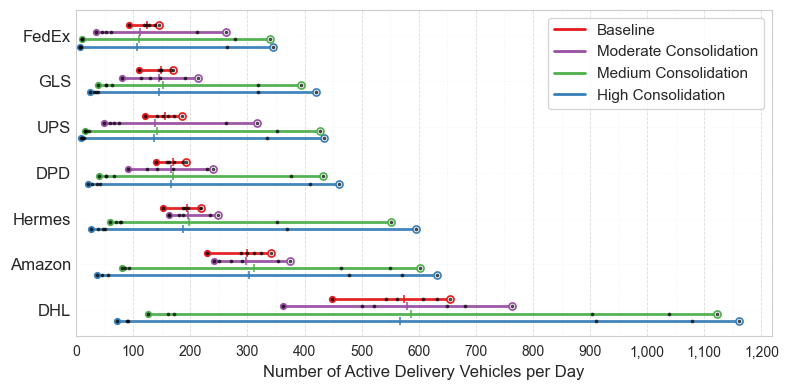

In [13]:
## =============================================================================
# Lollipop per scenario: per-carrier weekly min, mean, and max vehicles (providers visible)
# =============================================================================
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, MultipleLocator

# --- 1) Prepare scenario, weekday, provider -----------------------------------
work = df.copy()

# Common weekday map (EN->DE) used for both detection and normalization
map_en_de = {
    "Monday":"Montag","Tuesday":"Dienstag","Wednesday":"Mittwoch",
    "Thursday":"Donnerstag","Friday":"Freitag","Saturday":"Samstag"
}

# Scenario column (fallback from run_name if missing)
if "scenario" not in work.columns and "run_name" in work.columns:
    work["scenario"] = work["run_name"].astype(str).str.split("_").str[0]

def _weekday_from_runname(run_name):
    m = re.search(r"_(\d{8})_", str(run_name))
    if not m:
        return None
    dt = datetime.strptime(m.group(1), "%d%m%Y")
    return map_en_de.get(dt.strftime("%A"))

# Weekday column: use existing if present; otherwise derive from run_name
if "weekday" in work.columns:
    w_raw = work["weekday"].astype(str)
    w_mapped = w_raw.map(map_en_de)
    work["weekday"] = w_mapped.fillna(w_raw)  # keep german if already german
elif "run_name" in work.columns:
    work["weekday"] = work["run_name"].apply(_weekday_from_runname)
else:
    raise RuntimeError("No weekday information: neither 'weekday' nor 'run_name' available.")

if "provider" not in work.columns:
    raise RuntimeError("Column 'provider' missing in df_all/df")

weekday_order = ["Montag","Dienstag","Mittwoch","Donnerstag","Freitag","Samstag"]
work["weekday"] = pd.Categorical(work["weekday"], categories=weekday_order, ordered=True)

# Scenario label mapping: prefer global mapping and order if present
scenario_display_local = scenario_display if "scenario_display" in globals() else {
    "basecase":"Baseline",
    "batchmoderate":"Moderate Consolidation",
    "batchmedium":"Medium Consolidation",
    "batchhigh":"High Consolidation",
}
work["scenario_label"] = work["scenario"].astype(str).map(scenario_display_local).fillna(work["scenario"].astype(str))
label_replace = {
    "Moderate Cost": "Moderate Consolidation",
    "Medium Cost": "Medium Consolidation",
    "High Cost": "High Consolidation",
}
work["scenario_label"] = work["scenario_label"].replace(label_replace)
present_labels = work["scenario_label"].dropna().astype(str).unique().tolist()

scenario_order_local = None
if "scenario_order" in globals() and scenario_order:
    scenario_order_local = [s for s in scenario_order if s in present_labels] + [s for s in present_labels if s not in scenario_order]
elif "scenarios_plot" in globals() and "BASELINE" in globals():
    pref = [str(BASELINE)] + [str(s) for s in scenarios_plot]
    scenario_order_local = [scenario_display_local.get(s, s) for s in pref if scenario_display_local.get(s, s) in present_labels] + [s for s in present_labels if s not in pref]
else:
    scenario_order_local = sorted(present_labels)

scenario_order_local = [label_replace.get(s, s) for s in scenario_order_local]
if not scenario_order_local:
    raise RuntimeError(f"No scenarios present in data. Found labels: {present_labels}")

if work.dropna(subset=["weekday"]).empty:
    raise RuntimeError("No rows with weekdays present after preprocessing. Check weekday values or run_name format.")

# --- 2) Aggregate per-day vehicle counts --------------------------------------
if "run_name" in work.columns:
    per_run = (
        work.dropna(subset=["weekday"])
            .groupby(["scenario_label","provider","weekday","run_name"], dropna=False)
            .size().reset_index(name="vehicles")
    )
    per_day = (
        per_run.groupby(["scenario_label","provider","weekday"], dropna=False)["vehicles"]
               .max().reset_index()
    )
else:
    per_day = (
        work.dropna(subset=["weekday"])
            .groupby(["scenario_label","provider","weekday"], dropna=False)
            .size().reset_index(name="vehicles")
    )

# --- 3) Weekly min, mean, max per carrier per scenario -------------------------
weekly_stats = (
    per_day.groupby(["scenario_label","provider"], dropna=False)["vehicles"]
           .agg(week_min="min", week_mean="mean", week_max="max")
           .reset_index()
)
if weekly_stats.empty:
    raise RuntimeError("No weekly vehicle stats computed. Check provider/scenario/weekday data.")

# --- 4) Provider order (no anonymization, tidy names) --------------------------
name_map = {
    "dhl":"DHL",
    "hermes":"Hermes",
    "dpd":"DPD",
    "gls":"GLS",
    "ups":"UPS",
    "amazon":"Amazon",
    "fedex":"FedEx",
}
def _clean_provider(p):
    if p is None:
        return p
    key = str(p).strip().lower()
    return name_map.get(key, str(p).strip())
weekly_stats["provider_display"] = weekly_stats["provider"].apply(_clean_provider)
provider_display_map = dict(zip(weekly_stats["provider"], weekly_stats["provider_display"]))
provider_order = (
    weekly_stats.groupby("provider")["week_max"]
    .max()
    .sort_values(ascending=False)
    .index.tolist()
)
provider_order_display = [provider_display_map.get(p, p) for p in provider_order]
if not provider_order_display:
    raise RuntimeError("No providers after grouping. Check provider values.")

# --- Build full matrix in the exact desired order ---
idx = pd.MultiIndex.from_product([provider_order_display, scenario_order_local],
                                 names=["provider_display", "scenario_label"])
plot_df = (
    weekly_stats.set_index(["provider_display", "scenario_label"])
                .reindex(idx)               # <- respects both orders
                .reset_index()
)

# --- 6) Plot setup -------------------------------------------------------------
sns.set_style("whitegrid")
palette = sns.color_palette("Set1", len(scenario_order_local))
colors = dict(zip(scenario_order_local, palette))

# Offsets vertically per scenario
offset_map = {
    "Baseline":                0.24,
    "Moderate Consolidation":  0.08,
    "Medium Consolidation":   -0.08,
    "High Consolidation":     -0.24,
}
default_offset = 0.0

# Create figure
fig, ax = plt.subplots(figsize=(8, max(4, 0.40*len(provider_order_display))))
y_base = np.arange(len(provider_order_display))
ax.set_yticks(y_base)
ax.set_yticklabels(provider_order_display, fontsize=12)

xmax_global = float(plot_df["week_max"].max()) if plot_df["week_max"].notna().any() else 1.0
ax.set_xlim(0.0, xmax_global * 1.05)

# --- 7) Draw lollipops with mean markers + weekday dots (on scenario line) -----
for i, scen in enumerate(scenario_order_local):
    sub = plot_df[plot_df["scenario_label"] == scen].set_index("provider_display").reindex(provider_order_display)
    c = colors.get(scen, (0.4, 0.4, 0.4))
    y = y_base + offset_map.get(scen, default_offset)

    x_min = sub["week_min"].fillna(0.0).values
    x_max = sub["week_max"].fillna(0.0).values
    x_mean = sub["week_mean"].fillna(0.0).values

    z = 10 + i
    # Lollipop line
    ax.hlines(y=y, xmin=x_min, xmax=x_max, color=c, alpha=0.95, linewidth=2.0, zorder=z)
    # Min marker
    ax.scatter(x_min, y, s=18, color=c, alpha=0.95, zorder=z+1)
    # Max marker (white)
    ax.scatter(x_max, y, s=26, facecolors="white", edgecolors=c, linewidths=1.2, zorder=z+2)
    # Mean marker (small X)
    ax.scatter(x_mean, y, marker="|", s=35, color=c, linewidths=1.1, zorder=z+3)

    # Small weekday dots directly on scenario line (no labels)
    per_day_sub = per_day[per_day["scenario_label"] == scen].copy()
    for p_disp, y0 in zip(provider_order_display, y_base):
        rows = per_day_sub[per_day_sub["provider"].map(provider_display_map) == p_disp]
        if rows.empty:
            continue
        for _, r in rows.iterrows():
            veh = float(r["vehicles"]) if pd.notna(r["vehicles"]) else np.nan
            if not np.isfinite(veh):
                continue
            ax.scatter(veh, y0 + offset_map.get(scen, default_offset), s=3, color="black", alpha=0.6, zorder=z+40)

# --- 8) Formatting ------------------------------------------------------------
ax.set_xlabel(
    "Number of Active Delivery Vehicles per Day",
    fontsize=12
)
# ax.set_ylabel("Logistics Service Provider", fontsize=11)
ax.xaxis.set_major_locator(MultipleLocator(100))
ax.xaxis.set_minor_locator(MultipleLocator(50))
ax.grid(axis="x", linestyle="--", linewidth=0.6, color="0.8", alpha=0.7)
ax.grid(axis="x", which="minor", linestyle=":", linewidth=0.4, color="0.85", alpha=0.6)
ax.grid(axis="y", linestyle=":", linewidth=0.4, color="0.9", alpha=0.6)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{int(x):,}"))

# Legend in requested order (Baseline, Medium, Moderate, High)
legend_order = ["Baseline", "Moderate Consolidation","Medium Consolidation", "High Consolidation"]
legend_order = [s for s in legend_order if s in plot_df["scenario_label"].unique()]
handles = [
    Line2D([0],[0], color=colors[s], lw=2.0, label=s)
    for s in legend_order
]
ax.legend(handles=handles, title="", ncols=1, fontsize=11, frameon=True, loc="upper right")

ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.savefig("lollipop_weekly_min_mean_max_per_carrier_all_scenarios.pdf", dpi=300, bbox_inches="tight")
plt.show()



In [ ]:
# =============================================================================
# Stacked bars: daily driven km per scenario, split into Non-batch vs Batch
# =============================================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from matplotlib.ticker import FuncFormatter

# ---------- 1) Prepare df ----------
work = df_all.copy()

# scenario
if "scenario" not in work.columns:
    if "run_name" not in work.columns:
        raise RuntimeError("run_name missing; cannot derive scenario")
    work["scenario"] = work["run_name"].astype(str).str.split("_").str[0]

# weekday (German)
map_en_de = {
    "Monday": "Montag", "Tuesday": "Dienstag", "Wednesday": "Mittwoch",
    "Thursday": "Donnerstag", "Friday": "Freitag", "Saturday": "Samstag", "Sunday": "Sonntag",
}
if "weekday" not in work.columns:
    def _weekday_from_runname(run_name):
        m = re.search(r"_(\d{8})_", str(run_name))
        if not m:
            return None
        try:
            dt = datetime.strptime(m.group(1), "%d%m%Y")
            return map_en_de.get(dt.strftime("%A"))
        except Exception:
            return None
    work["weekday"] = work["run_name"].apply(_weekday_from_runname)
else:
    work["weekday"] = work["weekday"].astype(str).str.strip().replace(map_en_de)

weekday_order = ["Montag","Dienstag","Mittwoch","Donnerstag","Freitag","Samstag"]
weekday_labels = ["Mon","Tue","Wed","Thu","Fri","Sat"]
work["weekday"] = pd.Categorical(work["weekday"], categories=weekday_order, ordered=True)

# activity_group (Batch Delivery Day vs Non-batch Delivery Day)
if "activity_group" not in work.columns:
    if "provider" not in work.columns:
        if "logisticProvider" in work.columns:
            work["provider"] = work["logisticProvider"].astype(str)
        elif "carrierID" in work.columns:
            work["provider"] = work["carrierID"].astype(str)
    provider_active_days = {
        "dhl": {"Montag","Mittwoch","Freitag"},
        "hermes": {"Dienstag","Samstag"},
        "dpd": {"Dienstag","Freitag"},
        "gls": {"Montag","Donnerstag"},
        "ups": {"Montag","Donnerstag"},
        "amazon": {"Dienstag","Donnerstag","Samstag"},
        "fedex": {"Montag","Donnerstag"},
    }
    def _is_active(row):
        prov = str(row.get("provider", "")).strip().lower()
        wd = str(row.get("weekday", "")).strip()
        return wd in provider_active_days.get(prov, set())
    work["active_flag"] = work.apply(_is_active, axis=1)
    work["activity_group"] = np.where(work["active_flag"], "Batch Delivery Day", "Non-batch Delivery Day")

# --- Force Baseline scenario to "Non-batch Delivery Day" ---
if "scenario" in work.columns and "activity_group" in work.columns:
    work.loc[work["scenario"].str.lower().str.contains("base"), "activity_group"] = "Non-batch Delivery Day"

# KPI column: total km per tour
if "Distance per Tour (km)" in work.columns:
    kpi = "Distance per Tour (km)"
elif "Tour Length (km)" in work.columns:
    work = work.rename(columns={"Tour Length (km)":"Distance per Tour (km)"})
    kpi = "Distance per Tour (km)"
else:
    raise RuntimeError("Neither 'Distance per Tour (km)' nor 'Tour Length (km)' found.")

work[kpi] = pd.to_numeric(work[kpi], errors="coerce")

# Scenario labels and order
scenario_display = {
    "basecase": "Baseline",
    "batchmoderate": "Moderate Consolidation",
    "batchmedium": "Medium Consolidation",
    "batchhigh": "High Consolidation",
}
work["scenario_label"] = work["scenario"].map(scenario_display).fillna(work["scenario"])
scenario_order = ["Baseline", "Moderate Consolidation", "Medium Consolidation", "High Consolidation"]
scen_present = [s for s in scenario_order if s in work["scenario_label"].unique().tolist()]
if not scen_present:
    scen_present = sorted(work["scenario_label"].unique().tolist())

# ---------- 2) Aggregate: daily sums split by activity_group ----------
daily = (
    work.dropna(subset=["weekday"])
        .groupby(["weekday","scenario_label","activity_group"], dropna=False)[kpi]
        .sum()
        .reset_index()
 )

# Ensure both stacks exist per day/scenario
all_keys = pd.MultiIndex.from_product([weekday_order, scen_present,
                                       ["Non-batch Delivery Day","Batch Delivery Day"]],
                                      names=["weekday","scenario_label","activity_group"])
daily = daily.set_index(["weekday","scenario_label","activity_group"]).reindex(all_keys).fillna(0.0).reset_index()

# Pivot to columns Batch / Non-batch for stacking
pivot = (
    daily.pivot_table(index=["weekday","scenario_label"], columns="activity_group", values=kpi, aggfunc="sum")
         .reset_index()
         .rename(columns={
             "Non-batch Delivery Day": "Non-batch km",
             "Batch Delivery Day": "Batch km"
         })
 )
pivot

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_61676\1426657248.py:98: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["weekday","scenario_label","activity_group"], dropna=False)[kpi]


activity_group,weekday,scenario_label,Batch km,Non-batch km
0,Dienstag,Baseline,0.000000,154676.646027
1,Dienstag,High Consolidation,142495.489600,20515.779705
2,Dienstag,Medium Consolidation,136992.218379,27830.094601
3,Dienstag,Moderate Consolidation,87479.290547,64097.640037
4,Donnerstag,Baseline,0.000000,171027.946172
5,Donnerstag,High Consolidation,168589.024088,26631.079290
6,Donnerstag,Medium Consolidation,166944.786916,38542.255517
7,Donnerstag,Moderate Consolidation,107995.984513,75243.522694
8,Freitag,Baseline,0.000000,154799.712243
9,Freitag,High Consolidation,109664.655742,24270.373690


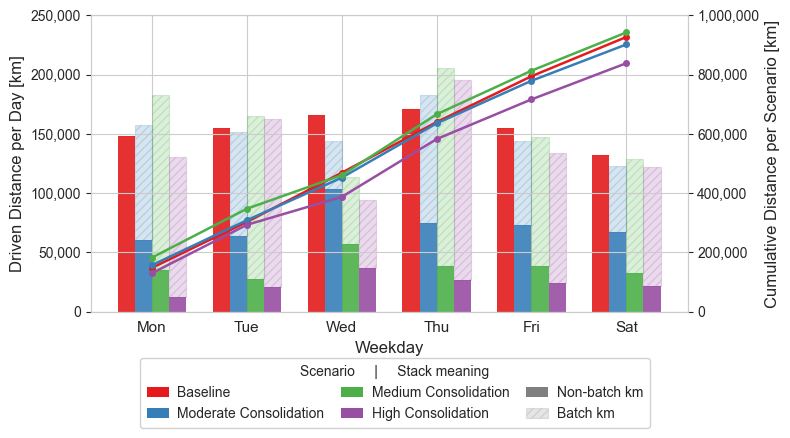

In [ ]:

# ---------- 3) Plot ----------
# =============================================================================
# Stacked bars + cumulative line with synchronized y-axes
# =============================================================================

sns.set_style("whitegrid")

palette = sns.color_palette("Set1", len(scenario_order))
colors = dict(zip(scenario_order, palette))

fig, ax1 = plt.subplots(figsize=(8, 4))

x_pos = np.arange(len(weekday_order))
width = 0.18
hatch_pattern = "////"
edge_lw = 0.8

# Helper for thousands separator
fmt = FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", " "))
ax1.yaxis.set_major_formatter(fmt)

# ---------- Bars (stacked) ----------
for i, scen in enumerate(scen_present):
    sub = pivot[pivot["scenario_label"] == scen].set_index("weekday").reindex(weekday_order)
    nonbatch = sub["Non-batch km"].to_numpy()
    batch = sub["Batch km"].to_numpy()
    xpos = x_pos + (i - (len(scen_present) - 1) / 2.0) * width
    base_col = colors.get(scen, (0.5, 0.5, 0.5))

    ax1.bar(
        xpos, nonbatch, width=width,
        color=base_col, alpha=0.9,
        edgecolor="none"
    )
    ax1.bar(
        xpos, batch, width=width, bottom=nonbatch,
        facecolor=base_col, alpha=0.2,
        hatch=hatch_pattern, edgecolor=base_col, linewidth=edge_lw
    )

# ---------- Second axis (cumulative lines) ----------
ax2 = ax1.twinx()

max_y = 0
for scen in scen_present:
    sub = pivot[pivot["scenario_label"] == scen].set_index("weekday").reindex(weekday_order)
    total = sub["Batch km"] + sub["Non-batch km"]
    cumulative = total.cumsum()
    max_y = max(max_y, cumulative.max())

    ax2.plot(
        x_pos, cumulative,
        color=colors[scen],
        linewidth=1.8,
        marker="o", markersize=4,
        label=f"{scen} cumulative"
    )

from matplotlib.ticker import MaxNLocator, FuncFormatter

# --- 1) Fix axis limits you want ---
# --- 1) Fixed axis limits ---
ax2_min, ax2_max = 0.0, 1_000_000.0     # right axis (cumulative)
ax1_min, ax1_max = 0.0,    250_000.0     # left axis (daily)
ax2.set_ylim(ax2_min, ax2_max)
ax1.set_ylim(ax1_min, ax1_max)

# --- 2) Generate “nice” ticks for the right axis ---
nbins = 6
ax2.yaxis.set_major_locator(MaxNLocator(nbins=nbins))
ax2_ticks = ax2.get_yticks()

# --- 3) Map those tick heights to the left axis (so grid lines match) ---
tick_fracs = (ax2_ticks - ax2_min) / (ax2_max - ax2_min)   # 0..1
ax1_ticks = ax1_min + tick_fracs * (ax1_max - ax1_min)
ax1.set_yticks(ax1_ticks)

# --- 4) Formatters ---
fmt = FuncFormatter(lambda v, _: f"{int(v):,}")
ax1.yaxis.set_major_formatter(fmt)
ax2.yaxis.set_major_formatter(fmt)

# --- 5) Grid ---
ax1.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
ax1.set_axisbelow(True)

# 5) Formatter beibehalten
ax1.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", ",")))
ax2.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", ",")))

# Optional: sicherstellen, dass das Grid exakt auf diesen (gemeinsamen) Tickpositionen liegt
ax1.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

# --- Achsenbeschriftungen & X-Ticks ---
ax1.set_xlabel("Weekday", fontsize=12)
ax1.set_ylabel("Driven Distance per Day [km]", fontsize=12)
ax2.set_ylabel("Cumulative Distance per Scenario [km]", fontsize=12)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(weekday_labels, fontsize=11)

# =========================
# Gemeinsame Legende unten
# =========================
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 4 Szenario-Farbflächen
scenario_handles = [Patch(facecolor=colors[s], edgecolor="none", label=s) for s in scen_present]

# 2 Stack-Bedeutungen (neutral grau dargestellt)
stack_handles = [
    Patch(facecolor="gray", edgecolor="none", label="Non-batch km"),
    Patch(facecolor="gray", alpha=0.20, hatch="////", edgecolor="gray", linewidth=0.8, label="Batch km"),
]

# zu einer Legende kombinieren
handles = scenario_handles + stack_handles
labels  = [h.get_label() for h in handles]

leg = fig.legend(
    handles, labels,
    loc="lower center", bbox_to_anchor=(0.5, -0.1),
    ncol=3, frameon=True, fancybox=True, framealpha=0.9,
    title="Scenario     |     Stack meaning",  # kurzer Titel
    handlelength=1.6, handletextpad=0.6, columnspacing=1.2, borderpad=0.5
)

# Damit unten Platz ist
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.savefig("distance_all_scenarios.pdf", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_61676\607035008.py:94: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["weekday","scenario_label","activity_group"], dropna=False)


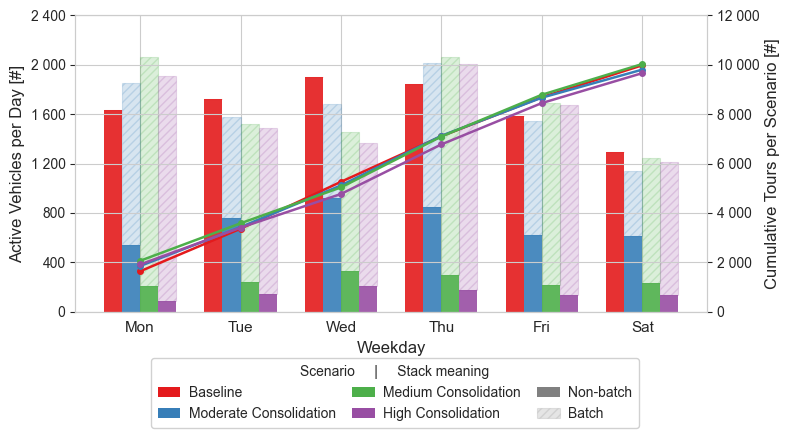


=== Vehicle (tour) count by scenario & activity_group ===
        scenario_label         activity_group  # Vehicles (tours)
              Baseline     Batch Delivery Day                   0
              Baseline Non-batch Delivery Day                9979
    High Consolidation     Batch Delivery Day                8780
    High Consolidation Non-batch Delivery Day                 881
  Medium Consolidation     Batch Delivery Day                8502
  Medium Consolidation Non-batch Delivery Day                1529
Moderate Consolidation     Batch Delivery Day                5503
Moderate Consolidation Non-batch Delivery Day                4301
              Baseline                  Total                9979
    High Consolidation                  Total                9661
  Medium Consolidation                  Total               10031
Moderate Consolidation                  Total                9804



In [ ]:
# =============================================================================
# Stacked bars: daily vehicle (tour) counts per scenario, split Non-batch/Batch
# + cumulative total tours per scenario (second y-axis, synced ticks)
# =============================================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from matplotlib.ticker import MaxNLocator, FuncFormatter
from matplotlib.patches import Patch

# ---------- 1) Prepare df (wie im Distanz-Plot) ----------
work = df_all.copy()

# scenario
if "scenario" not in work.columns:
    if "run_name" not in work.columns:
        raise RuntimeError("run_name missing; cannot derive scenario")
    work["scenario"] = work["run_name"].astype(str).str.split("_").str[0]

# weekday (German)
if "weekday" not in work.columns:
    def _weekday_from_runname(run_name):
        m = re.search(r"_(\d{8})_", str(run_name))
        if not m:
            return None
        dt = datetime.strptime(m.group(1), "%d%m%Y")
        map_en_de = {"Monday":"Montag","Tuesday":"Dienstag","Wednesday":"Mittwoch",
                     "Thursday":"Donnerstag","Friday":"Freitag","Saturday":"Samstag"}
        return map_en_de.get(dt.strftime("%A"))
    work["weekday"] = work["run_name"].apply(_weekday_from_runname)

weekday_order  = ["Montag","Dienstag","Mittwoch","Donnerstag","Freitag","Samstag"]
weekday_labels = ["Mon","Tue","Wed","Thu","Fri","Sat"]
weekday_map = {
    "monday": "Montag", "mon": "Montag", "1": "Montag",
    "tuesday": "Dienstag", "tue": "Dienstag", "tues": "Dienstag", "2": "Dienstag",
    "wednesday": "Mittwoch", "wed": "Mittwoch", "3": "Mittwoch",
    "thursday": "Donnerstag", "thu": "Donnerstag", "thur": "Donnerstag", "thurs": "Donnerstag", "4": "Donnerstag",
    "friday": "Freitag", "fri": "Freitag", "5": "Freitag",
    "saturday": "Samstag", "sat": "Samstag", "6": "Samstag",
}

def _normalize_weekday(val):
    if pd.isna(val):
        return None
    s = str(val).strip()
    key = s.lower()
    return weekday_map.get(key, s if s in weekday_order else None)

work["weekday"] = work["weekday"].apply(_normalize_weekday)
work = work.dropna(subset=["weekday"]).copy()
work["weekday"] = pd.Categorical(work["weekday"], categories=weekday_order, ordered=True)

# activity_group (Batch-Day vs Non-batch-Day)
if "activity_group" not in work.columns:
    provider_active_days = {
        "dhl": {"Montag","Mittwoch","Freitag"},
        "hermes": {"Dienstag","Samstag"},
        "dpd": {"Dienstag","Freitag"},
        "gls": {"Montag","Donnerstag"},
        "ups": {"Montag","Donnerstag"},
        "amazon": {"Dienstag","Donnerstag","Samstag"},
        "fedex": {"Montag","Donnerstag"},
    }
    def _is_active(row):
        prov = str(row.get("provider","")).strip().lower()
        wd   = str(row.get("weekday","")).strip()
        return wd in provider_active_days.get(prov, set())
    work["active_flag"]   = work.apply(_is_active, axis=1)
    work["activity_group"] = np.where(work["active_flag"], "Batch Delivery Day", "Non-batch Delivery Day")

# Baseline stets Non-batch
work.loc[work["scenario"].str.lower().str.contains("base"), "activity_group"] = "Non-batch Delivery Day"

# Szenario Labels / Reihenfolge / Farben
scenario_display = {
    "basecase": "Baseline",
    "batchmoderate": "Moderate Consolidation",
    "batchmedium":  "Medium Consolidation",
    "batchhigh":    "High Consolidation",
}
work["scenario_label"] = work["scenario"].map(scenario_display).fillna(work["scenario"])
scenario_order = ["Baseline","Moderate Consolidation","Medium Consolidation","High Consolidation"]
scen_present  = [s for s in scenario_order if s in work["scenario_label"].unique().tolist()] or \
                sorted(work["scenario_label"].unique().tolist())

# ---------- 2) Aggregate: tägliche Tour-Anzahlen je activity_group ----------
# Eine Zeile im df = eine Tour → zählen:
daily = (
    work.dropna(subset=["weekday"])
        .groupby(["weekday","scenario_label","activity_group"], dropna=False)
        .size()
        .reset_index(name="tours")
)

# Ensure both stacks per day/scenario
all_keys = pd.MultiIndex.from_product(
    [weekday_order, scen_present, ["Non-batch Delivery Day","Batch Delivery Day"]],
    names=["weekday","scenario_label","activity_group"]
)
daily = (daily.set_index(["weekday","scenario_label","activity_group"])
              .reindex(all_keys).fillna(0).reset_index())

# Pivot zu Spalten „Non-batch tours“ / „Batch tours“
pivot = (
    daily.pivot_table(index=["weekday","scenario_label"], columns="activity_group",
                      values="tours", aggfunc="sum")
         .reset_index()
         .rename(columns={
             "Non-batch Delivery Day": "Non-batch tours",
             "Batch Delivery Day":     "Batch tours"
         })
)

# ---------- 3) Plot ----------
sns.set_style("whitegrid")
palette = sns.color_palette("Set1", len(scenario_order))
colors  = dict(zip(scenario_order, palette))

fig, ax1 = plt.subplots(figsize=(8,4))
x_pos = np.arange(len(weekday_order))
width = 0.18
hatch_pattern = "////"
edge_lw = 0.8

# Bars (stacked)
for i, scen in enumerate(scen_present):
    sub = pivot[pivot["scenario_label"] == scen].set_index("weekday").reindex(weekday_order)
    nonbatch = sub["Non-batch tours"].to_numpy()
    batch    = sub["Batch tours"].to_numpy()
    xpos     = x_pos + (i - (len(scen_present)-1)/2.0)*width
    base_col = colors.get(scen, (0.5,0.5,0.5))

    ax1.bar(xpos, nonbatch, width=width, color=base_col, alpha=0.9, edgecolor="none")
    ax1.bar(xpos, batch,    width=width, bottom=nonbatch,
            facecolor=base_col, alpha=0.2, hatch=hatch_pattern,
            edgecolor=base_col, linewidth=edge_lw)

# Lines (cumulative total tours per scenario)
ax2   = ax1.twinx()
max_y = 0
for scen in scen_present:
    sub = pivot[pivot["scenario_label"] == scen].set_index("weekday").reindex(weekday_order)
    total = sub["Non-batch tours"] + sub["Batch tours"]
    cum   = total.cumsum()
    max_y = max(max_y, cum.max())
    ax2.plot(x_pos, cum, color=colors[scen], linewidth=1.8, marker="o", markersize=4,
             label=f"{scen} cumulative")

# ---------- 4) Synchronisierte Ticks ----------
# datengetriebene Bereiche mit Puffer
ax1_min, ax1_max = 0.0, max(10.0, 2400  if len(daily) else 10.0)
ax2_min, ax2_max = 0.0, max(10.0, 12000)

ax2.set_ylim(ax2_min, ax2_max)
ax1.set_ylim(ax1_min, ax1_max)

# schöne Ticks rechts, links gespiegelt
nbins = 6
ax2.yaxis.set_major_locator(MaxNLocator(nbins=nbins))
ax2_ticks = ax2.get_yticks()
tick_fracs = (ax2_ticks - ax2_min)/(ax2_max - ax2_min) if (ax2_max - ax2_min) else np.zeros_like(ax2_ticks)
ax1.set_yticks(ax1_min + tick_fracs*(ax1_max - ax1_min))

fmt = FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", " "))
ax1.yaxis.set_major_formatter(fmt)
ax2.yaxis.set_major_formatter(fmt)

# Achsen, Labels, X-Ticks
ax1.set_xlabel("Weekday", fontsize=12)
ax1.set_ylabel("Active Vehicles per Day [#]", fontsize=12)
ax2.set_ylabel("Cumulative Tours per Scenario [#]", fontsize=12)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(weekday_labels, fontsize=11)

ax1.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
ax1.set_axisbelow(True)

# Gemeinsame Legende unten (Szenarien + Stack-Bedeutung)
scenario_handles = [Patch(facecolor=colors[s], edgecolor="none", label=s) for s in scen_present]
stack_handles = [
    Patch(facecolor="gray", edgecolor="none", label="Non-batch"),
    Patch(facecolor="gray", alpha=0.20, hatch=hatch_pattern, edgecolor="gray", linewidth=edge_lw, label="Batch"),
]
handles = scenario_handles + stack_handles
labels  = [h.get_label() for h in handles]
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.1),
           ncol=3, frameon=True, fancybox=True, framealpha=0.9,
           title="Scenario     |     Stack meaning",
           handlelength=1.6, handletextpad=0.6, columnspacing=1.2, borderpad=0.5)

plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.savefig("vehicles_all_scenarios.pdf", dpi=300, bbox_inches="tight")
plt.show()

# ---------- 5) Optional: Summen drucken ----------
totals = (
    daily.assign(tours=lambda d: d["tours"].astype(int))
         .groupby(["scenario_label","activity_group"], dropna=False)["tours"]
         .sum()
         .reset_index()
)
totals_all = totals.groupby("scenario_label", as_index=False)["tours"].sum().assign(activity_group="Total")
print("\n=== Vehicle (tour) count by scenario & activity_group ===")
print(pd.concat([totals, totals_all], ignore_index=True)
        .rename(columns={"tours":"# Vehicles (tours)"}).to_string(index=False))
print("==========================================================\n")

In [ ]:
# =============================================================================
# Stacked bars: daily vehicle (tour) counts per scenario, split Non-batch/Batch
# + cumulative total tours per scenario (second y-axis, synced ticks)
# =============================================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from matplotlib.ticker import MaxNLocator, FuncFormatter
from matplotlib.patches import Patch

# ---------- 1) Prepare df (wie im Distanz-Plot) ----------
work = df_all.copy()

# scenario
if "scenario" not in work.columns:
    if "run_name" not in work.columns:
        raise RuntimeError("run_name missing; cannot derive scenario")
    work["scenario"] = work["run_name"].astype(str).str.split("_").str[0]

# Force weekday from run_name like "..._12052025_iter150_..."
digits = work["run_name"].astype(str).str.extract(r"(\d{8})", expand=False)

# Parse as ddmmyyyy and build weekday index 0..6
dates = pd.to_datetime(digits, format="%d%m%Y", errors="coerce")
dow = dates.dt.dayofweek  # Monday 0 ... Sunday 6

# Map to German weekday names
weekday_map = {0:"Montag", 1:"Dienstag", 2:"Mittwoch", 3:"Donnerstag", 4:"Freitag", 5:"Samstag"}
work["weekday"] = dow.map(weekday_map)

weekday_order  = ["Montag","Dienstag","Mittwoch","Donnerstag","Freitag","Samstag"]
weekday_labels = ["Mon","Tue","Wed","Thu","Fri","Sat"]
work["weekday"] = pd.Categorical(work["weekday"], categories=weekday_order, ordered=True)


# activity_group (Batch-Day vs Non-batch-Day)
if "activity_group" not in work.columns:
    provider_active_days = {
        "dhl": {"Montag","Mittwoch","Freitag"},
        "hermes": {"Dienstag","Samstag"},
        "dpd": {"Dienstag","Freitag"},
        "gls": {"Montag","Donnerstag"},
        "ups": {"Montag","Donnerstag"},
        "amazon": {"Dienstag","Donnerstag","Samstag"},
        "fedex": {"Montag","Donnerstag"},
    }
    def _is_active(row):
        prov = str(row.get("provider","")).strip().lower()
        wd   = str(row.get("weekday","")).strip()
        return wd in provider_active_days.get(prov, set())
    work["active_flag"]   = work.apply(_is_active, axis=1)
    work["activity_group"] = np.where(work["active_flag"], "Batch Delivery Day", "Non-batch Delivery Day")

# Baseline stets Non-batch
work.loc[work["scenario"].str.lower().str.contains("base"), "activity_group"] = "Non-batch Delivery Day"

# Szenario Labels / Reihenfolge / Farben
scenario_display = {
    "basecase": "Baseline",
    "batchmoderate": "Moderate Cost",
    "batchmedium":  "Medium Cost",
    "batchhigh":    "High Cost",
}
work["scenario_label"] = work["scenario"].map(scenario_display).fillna(work["scenario"])
scenario_order = ["Baseline","Moderate Cost","Medium Cost","High Cost"]
scen_present  = [s for s in scenario_order if s in work["scenario_label"].unique().tolist()] or \
                sorted(work["scenario_label"].unique().tolist())

# ---------- 2) Aggregate: daily vehicle_cost per activity_group ----------
# Ensure vehicle_cost exists and is numeric
if "vehicle_cost" not in work.columns:
    raise RuntimeError("vehicle_cost missing in df_all/work")
work["vehicle_cost"] = pd.to_numeric(work["vehicle_cost"], errors="coerce").fillna(0.0)

# Sum costs per weekday x scenario x activity_group
daily = (
    work.dropna(subset=["weekday"])
        .groupby(["weekday", "scenario_label", "activity_group"], dropna=False)["vehicle_cost"]
        .sum()
        .reset_index(name="cost_sum")
)

# Ensure both stacks per day and scenario exist
all_keys = pd.MultiIndex.from_product(
    [weekday_order, scen_present, ["Non-batch Delivery Day", "Batch Delivery Day"]],
    names=["weekday", "scenario_label", "activity_group"]
)
daily = (
    daily.set_index(["weekday", "scenario_label", "activity_group"])
         .reindex(all_keys)
         .fillna(0.0)
         .reset_index()
)

# Pivot to columns "Non-batch cost" and "Batch cost"
pivot = (
    daily.pivot_table(
        index=["weekday", "scenario_label"],
        columns="activity_group",
        values="cost_sum",
        aggfunc="sum",
        fill_value=0.0
    )
    .reset_index()
    .rename(columns={
        "Non-batch Delivery Day": "Non-batch cost",
        "Batch Delivery Day": "Batch cost"
    })
)

# Optional: total and cumulative total cost per scenario for a second y axis
pivot["Total cost"] = pivot["Non-batch cost"] + pivot["Batch cost"]
pivot = pivot.sort_values(["scenario_label", "weekday"], key=lambda s: s.map({d:i for i,d in enumerate(weekday_order)}))
pivot["Cumulative cost"] = pivot.groupby("scenario_label")["Total cost"].cumsum()

pivot


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_61676\2899034975.py:81: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["weekday", "scenario_label", "activity_group"], dropna=False)["vehicle_cost"]


activity_group,weekday,scenario_label,Batch cost,Non-batch cost,Total cost,Cumulative cost
16,Montag,Baseline,0.000000,372567.362156,372567.362156,3.725674e+05
17,Montag,High Cost,385390.165433,21252.020051,406642.185484,4.066422e+05
18,Montag,Medium Cost,401435.999268,53658.772210,455094.771478,4.550948e+05
19,Montag,Moderate Cost,291386.077562,127205.359198,418591.436760,4.185914e+05
0,Dienstag,Baseline,0.000000,393605.433560,393605.433560,7.661728e+05
1,Dienstag,High Cost,304446.478569,35073.669154,339520.147723,7.461623e+05
2,Dienstag,Medium Cost,290710.892774,55906.442256,346617.335030,8.017121e+05
3,Dienstag,Moderate Cost,192342.443215,171026.568342,363369.011557,7.819604e+05
12,Mittwoch,Baseline,0.000000,431069.349447,431069.349447,1.197242e+06
13,Mittwoch,High Cost,234379.029804,53036.934283,287415.964087,1.033578e+06


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_39664\3888695815.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  work.groupby(['scenario','weekday','run_name'], dropna=False)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_39664\3888695815.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['scenario','weekday'], as_index=False)['cost_per_parcel_day']
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_39664\3888695815.py:105: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or

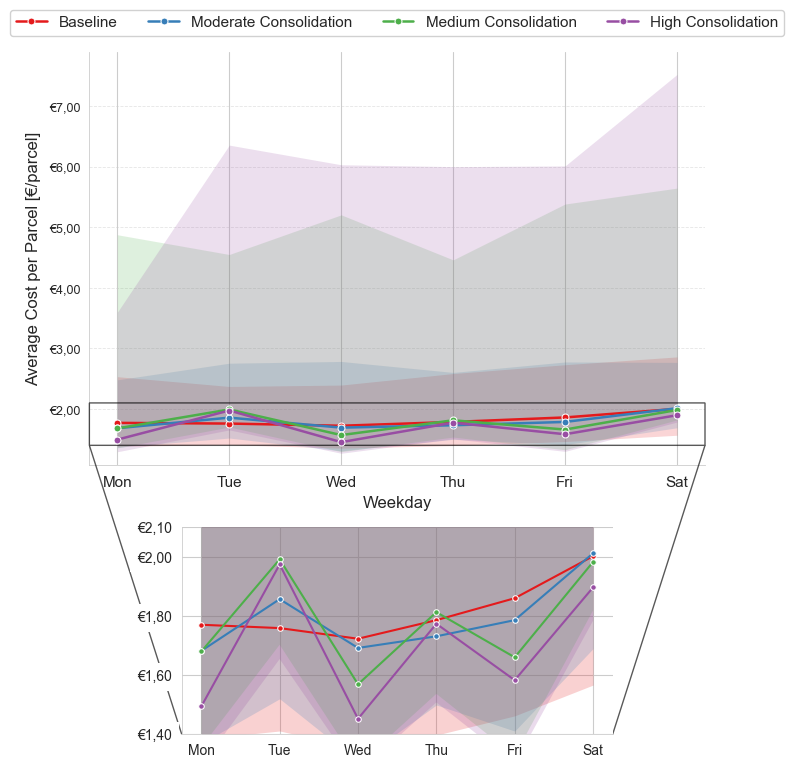

In [55]:
# =============================================================================
# Average Cost per Parcel by Weekday (Mon–Sat), paper-ready plot
# =============================================================================
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ---------- 0) Preconditions ----------
if 'df_all' not in globals() or df_all is None or len(df_all) == 0:
    raise RuntimeError("df_all is empty or not loaded.")

work = df_all.copy()

# Required numeric inputs
for col in ['vehicle_cost', 'deliveries']:
    if col not in work.columns:
        raise RuntimeError(f"Required column '{col}' missing in df_all.")
work['vehicle_cost'] = pd.to_numeric(work['vehicle_cost'], errors='coerce').fillna(0.0)
work['deliveries']   = pd.to_numeric(work['deliveries'],   errors='coerce').fillna(0.0)

# Scenario from run_name prefix
if 'run_name' not in work.columns:
    raise RuntimeError("'run_name' missing in df_all; ensure loader added it.")
work['scenario'] = work['run_name'].astype(str).str.split('_').str[0]

# ---------- 1) Weekday extraction ----------
from datetime import datetime as _dt

def _extract_day(run):
    m = re.search(r'_(\d{8})_', str(run))
    return m.group(1) if m else None

weekday_order  = ['Mon','Tue','Wed','Thu','Fri','Sat']
weekday_labels = weekday_order

def _weekday_label(day_token):
    try:
        d = _dt.strptime(day_token, '%d%m%Y').date()
        return ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][d.weekday()]
    except Exception:
        return None

work['day_token'] = work['run_name'].map(_extract_day)
work['weekday']   = work['day_token'].map(_weekday_label)
work = work[work['weekday'].isin(weekday_order)].copy()
work['weekday'] = pd.Categorical(work['weekday'], categories=weekday_order, ordered=True)

# ---------- 2) Aggregate: per-run day totals, then average over runs ----------
per_run = (
    work.groupby(['scenario','weekday','run_name'], dropna=False)
        .agg(total_cost=('vehicle_cost','sum'),
             total_deliveries=('deliveries','sum'))
        .reset_index()
)
per_run['cost_per_parcel_day'] = np.where(
    per_run['total_deliveries'] > 0,
    per_run['total_cost'] / per_run['total_deliveries'],
    np.nan
)

avg_cpp = (per_run
           .groupby(['scenario','weekday'], as_index=False)['cost_per_parcel_day']
           .mean())

# ---------- 3) Pretty labels, order, palette ----------
scenario_display = {
    "basecase":      "Baseline",
    "batchmoderate": "Moderate Cost",
    "batchmedium":   "Medium Cost",
    "batchhigh":     "High Cost",
}
avg_cpp['scenario_label'] = avg_cpp['scenario'].map(scenario_display).fillna(avg_cpp['scenario'])

scenario_order = ["Baseline","Moderate Cost","Medium Cost","High Cost"]
present = [s for s in scenario_order if s in avg_cpp['scenario_label'].unique()]
if not present:
    present = sorted(avg_cpp['scenario_label'].unique())

palette = sns.color_palette("Set1", len(scenario_order))
color_map = dict(zip(scenario_order, palette))

# ---------- 4) Plot (paper-ready) ----------
sns.set_style("whitegrid")
plt.figure(figsize=(8, 5.3))

def euro_fmt(v, _):
    if pd.isna(v):
        return ""
    return f"€{v:,.2f}".replace(",", " ").replace(".", ",")

ax = sns.lineplot(
    data=avg_cpp.sort_values(['scenario_label','weekday']),
    x='weekday', y='cost_per_parcel_day',
    hue='scenario_label', hue_order=present,
    palette=color_map,
    marker='o', markersize=5, linewidth=1.8,  zorder=9999
)

per_run_carrier = (
    work.groupby(['scenario','provider','weekday','run_name'], dropna=False)
        .agg(total_cost=('vehicle_cost','sum'),
             total_deliveries=('deliveries','sum'))
        .reset_index()
)
per_run_carrier['cost_per_parcel_day'] = np.where(
    per_run_carrier['total_deliveries'] > 0,
    per_run_carrier['total_cost'] / per_run_carrier['total_deliveries'],
    np.nan
)

# Average per carrier (per scenario x weekday)
avg_cpp_carrier = (
    per_run_carrier.groupby(['scenario','provider','weekday'], as_index=False)['cost_per_parcel_day']
                   .mean()
)

for df_ in [avg_cpp, avg_cpp_carrier]:
    df_['scenario_label'] = df_['scenario'].map(scenario_display).fillna(df_['scenario'])

# --- Scenario bands: min/max of carrier averages per weekday ---
draw_order = ["Baseline", "Moderate Cost", "Medium Cost", "High Cost"][:]
weekday_idx = dict(zip(weekday_order, range(len(weekday_order))))  # {"Mon":0,...}

for z, scen in enumerate(draw_order, start=1):
    if scen not in avg_cpp_carrier["scenario_label"].unique():
        continue
    col = color_map[scen]

    sub = avg_cpp_carrier.loc[avg_cpp_carrier["scenario_label"] == scen,
                              ["weekday", "cost_per_parcel_day"]].copy()

    band = (sub.groupby("weekday", as_index=False)["cost_per_parcel_day"]
              .agg(low='min', high='max')
              .sort_values("weekday"))

    x = band["weekday"].map(weekday_idx).to_numpy()
    low = band["low"].to_numpy()
    high = band["high"].to_numpy()

    ax.fill_between(
        x, low, high, color=col, alpha=0.18, linewidth=0, zorder=z
    )
        
# Axes & labels
ax.set_xlabel("Weekday", fontsize=12)
ax.set_ylabel("Average Cost per Parcel [€/parcel]", fontsize=12, labelpad=6)
ax.set_xticks(range(len(weekday_labels)))
ax.set_xticklabels(weekday_labels, fontsize=11, ha='center')
ax.yaxis.set_major_formatter(FuncFormatter(euro_fmt))
ax.tick_params(axis='y', direction='in', pad=6)
ax.tick_params(axis='x', pad=4)

# Grid & spines
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
for spine in ["top","right"]:
    ax.spines[spine].set_visible(False)

# Legend above to free bottom space
leg = ax.legend(
    loc="upper center", bbox_to_anchor=(0.5, 1.12),
    ncol=len(present), frameon=True, fancybox=True, framealpha=0.9, fontsize = 11
)
# Rename legend labels to Consolidation
for txt in leg.get_texts():
    txt.set_text(txt.get_text().replace("Cost", "Consolidation"))
plt.tight_layout()

# Y-limits: keep full range on main, plus a zoomed inset placed below
y_min_main = max(0, np.nanmin(per_run_carrier['cost_per_parcel_day']) - 0.2)
y_max_main = np.nanmax(per_run_carrier['cost_per_parcel_day']) * 1.05
ax.set_ylim(y_min_main, y_max_main)

# Zoom inset for the informative range (centered below)
y_focus_min, y_focus_max = 1.4, 2.1
ax_inset = inset_axes(
    ax, width="70%", height="50%", loc="lower center",
    bbox_to_anchor=(0, -0.65, 1, 1), bbox_transform=ax.transAxes, borderpad=0,
 )
sns.lineplot(
    data=avg_cpp.sort_values(['scenario_label','weekday']),
    x='weekday', y='cost_per_parcel_day',
    hue='scenario_label', hue_order=present,
    palette=color_map,
    marker='o', markersize=4, linewidth=1.5,  ax=ax_inset, legend=False
)

for z, scen in enumerate(draw_order, start=1):
    if scen not in avg_cpp_carrier["scenario_label"].unique():
        continue
    col = color_map[scen]
    sub = avg_cpp_carrier.loc[avg_cpp_carrier["scenario_label"] == scen,
                              ["weekday", "cost_per_parcel_day"]].copy()
    band = (sub.groupby("weekday", as_index=False)["cost_per_parcel_day"]
              .agg(low='min', high='max')
              .sort_values("weekday"))
    x = band["weekday"].map(weekday_idx).to_numpy()
    low = band["low"].to_numpy()
    high = band["high"].to_numpy()
    ax_inset.fill_between(x, low, high, color=col, alpha=0.20, linewidth=0)

ax_inset.set_ylim(y_focus_min, y_focus_max)
ax_inset.set_yticks([1.4, 1.6, 1.8, 2.0, 2.1])
ax_inset.yaxis.set_major_formatter(FuncFormatter(euro_fmt))
ax_inset.set_xlabel("")
ax_inset.set_ylabel("")
ax_inset.tick_params(axis='x', labelrotation=0, labelsize=10)
ax_inset.tick_params(axis='y', labelsize=10)
for spine in ["top","right"]:
    ax_inset.spines[spine].set_visible(False)
    
for label in ax_inset.get_yticklabels():
    label.set_bbox(dict(facecolor="white", edgecolor="none", pad=5))
ax.indicate_inset_zoom(ax_inset, edgecolor="black", alpha=0.65)

plt.savefig("avg_cost_per_parcel_by_weekday.pdf", dpi=300, bbox_inches="tight")

plt.show()


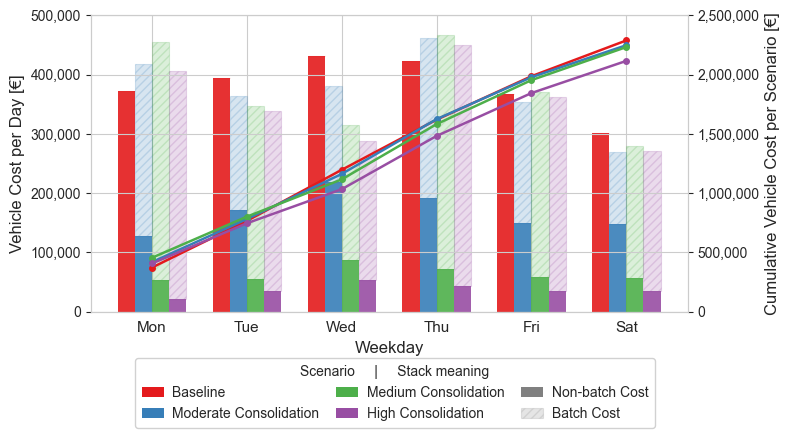

In [ ]:
# ---------- 3) Plot ----------
# =============================================================================
# Stacked bars + cumulative line with synchronized y-axes
# =============================================================================

# ---------- 3) Scenario labels/order ----------
scenario_display = {
    "basecase": "Baseline",
    "batchmoderate": "Moderate Cost",
    "batchmedium": "Medium Cost",
    "batchhigh": "High Cost",
}

# Ensure scenario_label exists where needed
if "work" in globals():
    work["scenario_label"] = work["scenario"].map(scenario_display).fillna(work["scenario"])

if "per_run" in globals():
    per_run["scenario_label"] = per_run["scenario"].map(scenario_display).fillna(per_run["scenario"])

if "avg_cpp" in globals():
    avg_cpp["scenario_label"] = avg_cpp["scenario"].map(scenario_display).fillna(avg_cpp["scenario"])

# Also ensure pivot has scenario_label
if "pivot" in globals() and "scenario" in pivot.columns:
    pivot["scenario_label"] = pivot["scenario"].map(scenario_display).fillna(pivot["scenario"])

scenario_order = ["Baseline", "Moderate Cost", "Medium Cost", "High Cost"]
present = [s for s in scenario_order if s in avg_cpp['scenario_label'].unique()]
if not present:
    present = sorted(avg_cpp['scenario_label'].unique())

palette = sns.color_palette("Set1", len(scenario_order))
color_map = dict(zip(scenario_order, palette))

if "work" not in globals():
    raise RuntimeError("work is not defined; run the data prep cell before plotting.")
scen_present = [s for s in scenario_order if s in work["scenario_label"].unique().tolist()]
if not scen_present:
    scen_present = sorted(work["scenario_label"].unique().tolist())

sns.set_style("whitegrid")

palette = sns.color_palette("Set1", len(scenario_order))
colors = dict(zip(scenario_order, palette))

fig, ax1 = plt.subplots(figsize=(8, 4))

# Weekdays: German names for indexing, English labels for display
weekday_order_de  = ["Montag", "Dienstag", "Mittwoch", "Donnerstag", "Freitag", "Samstag"]
weekday_labels_en = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]

x_pos = np.arange(len(weekday_order_de))
width = 0.18
hatch_pattern = "////"
edge_lw = 0.8

# Helper for thousands separator
fmt = FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", " "))
ax1.yaxis.set_major_formatter(fmt)

# ---------- Bars (stacked) ----------
for i, scen in enumerate(scen_present):
    sub = pivot[pivot["scenario_label"] == scen].set_index("weekday").reindex(weekday_order_de)
    nonbatch = sub["Non-batch cost"].fillna(0).to_numpy()
    batch = sub["Batch cost"].fillna(0).to_numpy()
    xpos = x_pos + (i - (len(scen_present) - 1) / 2.0) * width
    base_col = colors.get(scen, (0.5, 0.5, 0.5))

    ax1.bar(
        xpos, nonbatch, width=width,
        color=base_col, alpha=0.9,
        edgecolor="none"
    )
    ax1.bar(
        xpos, batch, width=width, bottom=nonbatch,
        facecolor=base_col, alpha=0.2,
        hatch=hatch_pattern, edgecolor=base_col, linewidth=edge_lw
    )

# ---------- Second axis (cumulative lines) ----------
ax2 = ax1.twinx()

max_y = 0
for scen in scen_present:
    sub = pivot[pivot["scenario_label"] == scen].set_index("weekday").reindex(weekday_order_de)
    total = sub["Batch cost"].fillna(0) + sub["Non-batch cost"].fillna(0)
    cumulative = total.cumsum()
    max_y = max(max_y, cumulative.max())

    ax2.plot(
        x_pos, cumulative,
        color=colors[scen],
        linewidth=1.8,
        marker="o", markersize=4,
        label=f"{scen} cumulative"
    )

from matplotlib.ticker import MaxNLocator, FuncFormatter

# --- 1) Fixed axis limits ---
ax2_min, ax2_max = 0.0, 2_500_000.0     # right axis (cumulative)
ax1_min, ax1_max = 0.0,    500_000.0     # left axis (daily)
ax2.set_ylim(ax2_min, ax2_max)
ax1.set_ylim(ax1_min, ax1_max)

# --- 2) Generate "nice" ticks for the right axis ---
nbins = 6
ax2.yaxis.set_major_locator(MaxNLocator(nbins=nbins))
ax2_ticks = ax2.get_yticks()

# --- 3) Map those tick heights to the left axis (so grid lines match)
tick_fracs = (ax2_ticks - ax2_min) / (ax2_max - ax2_min)   # 0..1
ax1_ticks = ax1_min + tick_fracs * (ax1_max - ax1_min)
ax1.set_yticks(ax1_ticks)

# --- 4) Formatters ---
fmt = FuncFormatter(lambda v, _: f"{int(v):,}")
ax1.yaxis.set_major_formatter(fmt)
ax2.yaxis.set_major_formatter(fmt)

# --- 5) Grid ---
ax1.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
ax1.set_axisbelow(True)

# --- Achsenbeschriftungen & X-Ticks ---
ax1.set_xlabel("Weekday", fontsize=12)
ax1.set_ylabel("Vehicle Cost per Day [€]", fontsize=12)
ax2.set_ylabel("Cumulative Vehicle Cost per Scenario [€]", fontsize=12)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(weekday_labels_en, fontsize=11)
# =========================
# Gemeinsame Legende unten
# =========================
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 4 Szenario-Farbflächen
scenario_handles = [Patch(facecolor=colors[s], edgecolor="none", label=s) for s in scen_present]

# 2 Stack-Bedeutungen (neutral grau dargestellt)
stack_handles = [
    Patch(facecolor="gray", edgecolor="none", label="Non-batch Cost"),
    Patch(facecolor="gray", alpha=0.20, hatch="////", edgecolor="gray", linewidth=0.8, label="Batch Cost"),
]

# zu einer Legende kombinieren
handles = scenario_handles + stack_handles
labels  = [h.get_label() for h in handles]

labels[1] = "Moderate Consolidation"
labels[2] = "Medium Consolidation"
labels[3] = "High Consolidation"

leg = fig.legend(
    handles, labels,
    loc="lower center", bbox_to_anchor=(0.5, -0.1),
    ncol=3, frameon=True, fancybox=True, framealpha=0.9,
    title="Scenario     |     Stack meaning",
    handlelength=1.6, handletextpad=0.6, columnspacing=1.2, borderpad=0.5
)

# Damit unten Platz ist
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.savefig("cost_all_scenarios.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
df_all

,vehicle_id,Start time,End time,Tour Duration (hrs),Service Duration,Driving Time (hrs),Start time formatted,End time formatted,Tour Duration formatted,Service Duration formatted,...,tour_km,initial_delivery_distance,vehicle_load_factor,is_van,is_ev,emissions,main_area_type_name,Cost per Parcel [€/parcel],weekday,scenario
0,freight_fedex_31832_veh_cep_size_m_7_1,24139.0,72066.0,13.313056,18233.0,8.248333,1970-01-01 06:42:19,1970-01-01 20:01:06,1970-01-01 13:18:47,1970-01-01 05:03:53,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.656254,Monday,basecase
1,freight_gls_31535_veh_cep_size_l_7_1,24722.0,64152.0,10.952778,10584.0,8.012778,1970-01-01 06:52:02,1970-01-01 17:49:12,1970-01-01 10:57:10,1970-01-01 02:56:24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.139754,Monday,basecase
2,freight_ups_31311_veh_cep_size_m_7_1,25075.0,69743.0,12.407778,14136.0,8.481111,1970-01-01 06:57:55,1970-01-01 19:22:23,1970-01-01 12:24:28,1970-01-01 03:55:36,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.246762,Monday,basecase
3,freight_ups_31832_veh_cep_size_m_7_1,25101.0,72941.0,13.288889,17985.0,8.293056,1970-01-01 06:58:21,1970-01-01 20:15:41,1970-01-01 13:17:20,1970-01-01 04:59:45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.695286,Monday,basecase
4,freight_gls_31535_veh_cep_size_m_7_5,25208.0,63241.0,10.564722,11392.0,7.400278,1970-01-01 07:00:08,1970-01-01 17:34:01,1970-01-01 10:33:53,1970-01-01 03:09:52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.574697,Monday,basecase
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39470,freight_amazon_30900_1_veh_cep_size_m_16_5,58148.0,64111.0,1.656389,1873.0,1.136111,1970-01-01 16:09:08,1970-01-01 17:48:31,1970-01-01 01:39:23,1970-01-01 00:31:13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.620688,Saturday,batchmoderate
39471,freight_amazon_31319_1_veh_cep_size_m_17_4,60689.0,74985.0,3.971111,3630.0,2.962778,1970-01-01 16:51:29,1970-01-01 20:49:45,1970-01-01 03:58:16,1970-01-01 01:00:30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.881250,Saturday,batchmoderate
39472,freight_amazon_30826_veh_cep_size_m_17_5,62458.0,71712.0,2.570556,4035.0,1.449722,1970-01-01 17:20:58,1970-01-01 19:55:12,1970-01-01 02:34:14,1970-01-01 01:07:15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.886592,Saturday,batchmoderate
39473,freight_amazon_31275_0_veh_cep_size_m_17_6,62620.0,67565.0,1.373611,1848.0,0.860278,1970-01-01 17:23:40,1970-01-01 18:46:05,1970-01-01 01:22:25,1970-01-01 00:30:48,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.183782,Saturday,batchmoderate


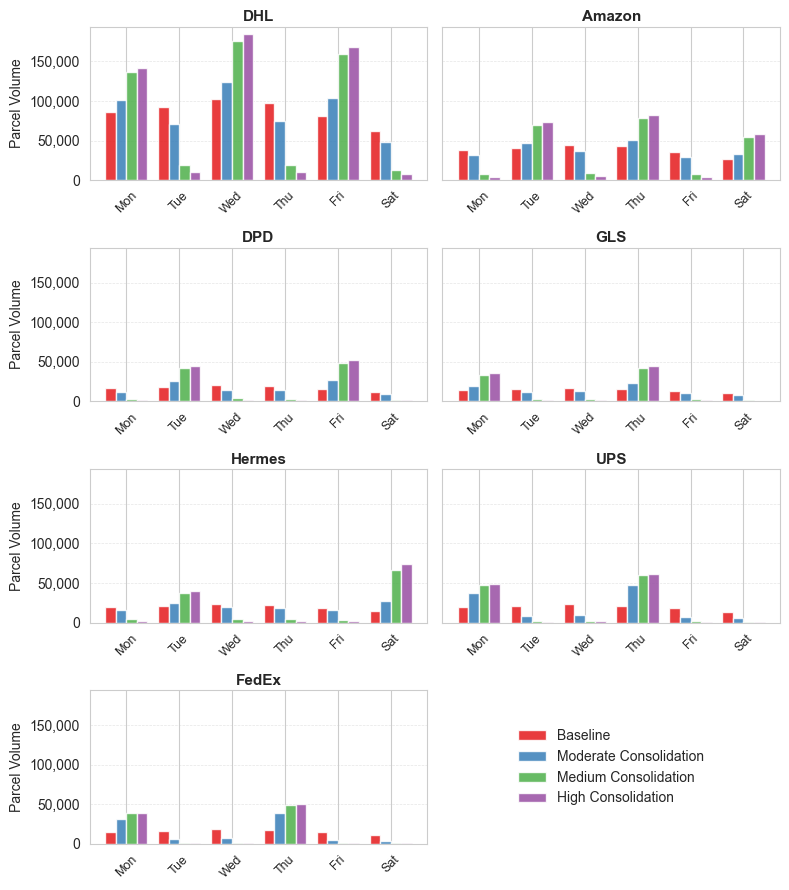

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter

def thousands_us(x, pos):
    return f"{int(x):,}"

plt.style.use("default")
sns.set_style("whitegrid")

# Provider-Mapping für Display-Labels
prov_labels = {
    "dhl": "DHL",
    "amazon": "Amazon",
    "dpd": "DPD",
    "gls": "GLS",
    "hermes": "Hermes",
    "ups": "UPS",
    "fedex": "FedEx",
}

# Szenario-Mapping
scenario_display = {
    "basecase": "Baseline",
    "batchmoderate": "Moderate Consolidation",
    "batchmedium": "Medium Consolidation",
    "batchhigh": "High Consolidation",
}

# Wochentag-Mapping
weekday_abbrev = {
    "Monday": "Mon",
    "Tuesday": "Tue",
    "Wednesday": "Wed",
    "Thursday": "Thu",
    "Friday": "Fri",
    "Saturday": "Sat",
}

# Provider und Szenario-Reihenfolge
selected_providers = ["dhl", "amazon", "dpd", "gls", "hermes", "ups", "fedex"]
scenario_order = ["Baseline", "Moderate Consolidation", "Medium Consolidation", "High Consolidation"]
day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]

# Daten vorbereiten: Gruppierung nach Provider, Szenario, Wochentag
df_plot = df_all.copy()
df_plot["provider_lower"] = df_plot["provider"].str.lower().str.strip()
df_plot["scenario_label"] = df_plot["scenario"].map(scenario_display).fillna(df_plot["scenario"])
df_plot["weekday_abbrev"] = df_plot["weekday"].map(weekday_abbrev).fillna(df_plot["weekday"])

# Aggregiere deliveries pro Provider, Scenario, Tag
records = (
    df_plot.groupby(["provider_lower", "scenario_label", "weekday_abbrev"], as_index=False)["deliveries"]
    .sum()
    .rename(columns={"deliveries": "Total"})
)
records["Carrier"] = records["provider_lower"].map(prov_labels).fillna(records["provider_lower"])
records["Scenario"] = records["scenario_label"]
records["Day"] = records["weekday_abbrev"]

# Filter auf relevante Provider und Szenarien
records = records[records["provider_lower"].isin(selected_providers)]
records = records[records["Scenario"].isin(scenario_order)]

# Kategorien setzen
records["Day"] = pd.Categorical(records["Day"], categories=day_order, ordered=True)
records["Scenario"] = pd.Categorical(records["Scenario"], categories=scenario_order, ordered=True)
records = records.sort_values(["Carrier", "Day", "Scenario"])

# Farben
palette = sns.color_palette("Set1", len(scenario_order))
colors = dict(zip(scenario_order, palette))

# Plot-Setup
n = len(selected_providers)
cols = 2
rows = int(np.ceil((n + 1) / cols))  # +1 für Legende
bar_width = 0.2
x = np.arange(len(day_order))
offsets = np.linspace(-1.5, 1.5, num=len(scenario_order)) * bar_width

fig, axes = plt.subplots(rows, cols, figsize=(8, 9), sharey=True)
axes = axes.flatten()

for i, prov in enumerate(selected_providers):
    ax = axes[i]
    carrier_label = prov_labels.get(prov, prov)
    df_c = records[records["provider_lower"] == prov]

    for j, scenario in enumerate(scenario_order):
        df_scen = df_c[df_c["Scenario"] == scenario].sort_values("Day")
        vals = []
        for d in day_order:
            row = df_scen[df_scen["Day"] == d]
            vals.append(row["Total"].values[0] if len(row) > 0 else 0)
        ax.bar(x + offsets[j], vals, width=bar_width,
               label=scenario if i == 0 else "", color=colors[scenario], alpha=0.85)

    ax.set_title(carrier_label, fontsize=11, fontweight="bold", pad=4)
    ax.set_xticks(x)
    ax.set_xticklabels(day_order, rotation=45, fontsize=9)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
    ax.yaxis.set_major_formatter(FuncFormatter(thousands_us))

    if i % cols == 0:
        ax.set_ylabel("Parcel Volume", fontsize=10)

# Legende im letzten Subplot
legend_ax_index = len(selected_providers)
legend_ax = axes[legend_ax_index]
legend_ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(handles, labels,
                 loc="center", fontsize=10, title_fontsize=10, frameon=False)

# Unbenutzte Achsen ausblenden
for j in range(len(selected_providers), len(axes)):
    if j != legend_ax_index:
        fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("parcel_volume_comparison_all_carriers.pdf", dpi=300)
plt.show()